# Analyse de la Base de Données de Production — Bontaz Tunisie
## Projet de Fin d'Année 2 · Génie Industriel · ENIT · 2025/2026
---
### Structure du notebook
| # | Section | Contenu |
|---|---------|---------|
| 1 | Installation & Configuration | Packages, imports, paramètres globaux |
| 2 | Chargement & Nettoyage | Lecture Excel, types, dates, colonnes |
| 3 | Rapport Qualité | Doublons, NaN, cohérence HT/HP |
| 4 | Analyse Exploratoire | Catégories, équipes, appareils, gammes |
| 5 | Détection & Correction des Outliers | IQR+Z+MAD, correction par médiane saine |
| 6 | Matrice de Corrélation | Relations entre variables numériques |
| 7 | KPI Globaux | Production, efficacité, taux utilisation |
| 8 | Analyse Temporelle | Annuelle, mensuelle, journalière |
| 9 | Saisonnalité | Heatmap Année×Mois, profil mensuel, pics |
| 10 | Calendrier & Jours Fériés | Jours travaillés vs arrêts, récurrence |
| 11 | Inventaire Codes | Appareils, gammes, classification, correspondance |
| 12 | KPI Annuels | Efficacité HP/HT, TRS, productivité brute/effective |
| 13 | Pareto 80/20 | Combinaisons appareil×gamme |
| 14 | Analyse des Pertes | Par appareil, Top 3 détaillé |
| 15 | Dashboard Exécutif | Synthèse visuelle complète |
| 16 | Préparation Prédiction | Série mensuelle, features temporels |
| 17 | Comparaison de Modèles | XGBoost, Random Forest, GradientBoosting, Ridge |
| 18 | Modèle Final & Validation | TimeSeriesSplit, intervalles de confiance |
| 19 | Importance Features & Résidus | Diagnostic du modèle |
| 20 | Export Résultats | Excel complet |

---
## 1. Installation des bibliothèques & Configuration globale
**Objectif :** vérifier et installer les packages nécessaires, configurer les paramètres d'affichage globaux.

In [1]:
import subprocess, sys, warnings
warnings.filterwarnings("ignore")


# Installation automatique des packages manquants
PACKAGES = {
    "xgboost"     : "xgboost",
    "lightgbm"    : "lightgbm",
    "statsmodels" : "statsmodels",
    "sklearn"     : "scikit-learn",
    "scipy"       : "scipy",
    "openpyxl"    : "openpyxl",
}
for module, pkg in PACKAGES.items():
    try:
        __import__(module)
        print(f"  OK  {pkg}")
    except ImportError:
        print(f"  Installation {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"  OK  {pkg}")
print("\nTous les packages sont prêts.")

  OK  xgboost
  OK  lightgbm
  OK  statsmodels
  OK  scikit-learn
  OK  scipy
  OK  openpyxl

Tous les packages sont prêts.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.dates     as mdates
import matplotlib.gridspec  as gridspec
import matplotlib.patches   as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
from pathlib import Path
from scipy   import stats as scipy_stats
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.model_selection import TimeSeriesSplit

# ── Paramètres globaux ───────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"         : 120,
    "axes.titlesize"     : 13,
    "axes.titleweight"   : "bold",
    "axes.labelsize"     : 11,
    "figure.facecolor"   : "white",
})
sns.set_theme(style="whitegrid", palette="husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

# ── Chemins ──────────────────────────────────────────────────────────────────
DATA_CANDIDATES = [
    Path(r"C:\Users\dell\Downloads\document pfa\prod_20-25.xlsx"),
    Path("prod_20-25.xlsx"),
    Path("Data/prod_20-25.xlsx"),
    Path("PFA_Analyse_production/Data/prod_20-25.xlsx"),
    Path("../Data/prod_20-25.xlsx"),
]
DESKTOP = Path(r"C:\Users\dell\Downloads\document pfa")

print("Configuration OK")

Configuration OK


---
## 2. Chargement & Nettoyage des données
**Objectif :** lire le fichier Excel de production, reconstruire les en-têtes, corriger les types, supprimer les colonnes inutiles et les erreurs de saisie connues (année 2001).

In [3]:
# ── Localisation du fichier ──────────────────────────────────────────────────
excel_path = next((p for p in DATA_CANDIDATES if p.exists()), None)
if excel_path is None:
    raise FileNotFoundError(
        "Fichier prod_20-25.xlsx introuvable.\n"
        "Ajoutez son chemin dans DATA_CANDIDATES en haut du notebook."
    )
print(f"Fichier : {excel_path}")

# ── Lecture brute ─────────────────────────────────────────────────────────────
raw = pd.read_excel(excel_path, skiprows=2, usecols="C:N")
raw.columns = raw.iloc[0]
raw = raw.iloc[1:].reset_index(drop=True)

# ── Suppression colonnes inutiles ─────────────────────────────────────────────
DROP = ["Nom opérateur", "Prénom opérateur", "Equipe Mp"]
raw = raw.drop(columns=[c for c in DROP if c in raw.columns])
# Nettoyer les espaces dans les noms de colonnes
raw = raw.rename(columns={"Désignation Appareil ": "Désignation Appareil"})

# ── Types de données ──────────────────────────────────────────────────────────
raw["Date de production"] = pd.to_datetime(raw["Date de production"], errors="coerce")

NUM_COLS = ["Heures travaillées", "Quantité produite", "Heures produites"]
STR_COLS = ["Code Usine", "Code appareil", "Code gamme", "Equipe", "Désignation Appareil"]

for c in NUM_COLS:
    if c in raw.columns:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
for c in STR_COLS:
    if c in raw.columns:
        raw[c] = raw[c].astype(str).str.strip()

# ── Suppression doublons ──────────────────────────────────────────────────────
n_dup = raw.duplicated().sum()
if n_dup:
    raw = raw.drop_duplicates().reset_index(drop=True)
    print(f"Doublons supprimés : {n_dup}")

# ── Correction erreur de saisie : année 2001 ─────────────────────────────────
mask_2001 = raw["Date de production"].dt.year == 2001
n_2001 = mask_2001.sum()
if n_2001:
    print(f"Lignes avec année 2001 (erreur de saisie) : {n_2001} — affectées à 2024")
    raw.loc[mask_2001, "Date de production"] = raw.loc[mask_2001, "Date de production"].apply(
        lambda d: d.replace(year=2024) if pd.notna(d) else d)

# ── Variables temporelles dérivées ────────────────────────────────────────────
raw["Année"]       = raw["Date de production"].dt.year
raw["Mois"]        = raw["Date de production"].dt.month
raw["Mois_Nom"]    = raw["Date de production"].dt.strftime("%B")
raw["Jour_Semaine"]= raw["Date de production"].dt.day_name()
raw["Semaine"]     = raw["Date de production"].dt.isocalendar().week.astype("Int64")
raw["Année_Mois"]  = raw["Date de production"].dt.to_period("M").astype(str)
raw["Date_Jour"]   = raw["Date de production"].dt.date
raw["Trimestre"]   = raw["Date de production"].dt.quarter

# Variable proxy pertes
raw["Heures_Perte"] = (raw["Heures travaillées"] - raw["Heures produites"]).clip(lower=0)

df = raw.copy()
print(f"\nDataframe final : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Période         : {df['Date de production'].min().date()} → {df['Date de production'].max().date()}")
df.head()

Fichier : C:\Users\dell\Downloads\document pfa\prod_20-25.xlsx
Lignes avec année 2001 (erreur de saisie) : 67 — affectées à 2024

Dataframe final : 114,259 lignes × 18 colonnes
Période         : 2020-01-06 → 2025-12-17


,Date de production,Equipe,Heures travaillées,Quantité produite,Heures produites,Code Usine,Code appareil,Désignation Appareil,Code gamme,Année,Mois,Mois_Nom,Jour_Semaine,Semaine,Année_Mois,Date_Jour,Trimestre,Heures_Perte
0,2025-12-17 08:27:34,NUIT,7.000,3830,6.383,TUNITB,X31,RETREINT (FELSS),1510930AATN1,2025,12,December,Wednesday,51,2025-12,2025-12-17,4,0.617
1,2025-12-17 08:27:34,NUIT,7.000,4930,6.993,TUNITB,X51,RETREINT (FELSS),1550620AATN2,2025,12,December,Wednesday,51,2025-12,2025-12-17,4,0.007
2,2025-12-17 08:27:34,NUIT,4.000,2315,2.572,TUNITB,X50,RETREINT (FELSS),1172470AATN0,2025,12,December,Wednesday,51,2025-12,2025-12-17,4,1.428
3,2025-12-17 08:27:34,NUIT,4.000,2375,2.639,TUNITB,X49,RETREINT (FELSS),1172470AATN0,2025,12,December,Wednesday,51,2025-12,2025-12-17,4,1.361
4,2025-12-17 08:27:34,NUIT,7.000,4230,6.043,TUNITB,X48,RETREINT (FELSS),1411830AATN1,2025,12,December,Wednesday,51,2025-12,2025-12-17,4,0.957


---
## 3. Rapport Qualité des Données
**Objectif :** vérifier exhaustivement la qualité du jeu de données — valeurs manquantes, doublons, cohérence métier (HP ≤ HT), valeurs négatives.

In [4]:
print("="*70)
print("RAPPORT QUALITÉ DES DONNÉES — BONTAZ TUNISIE")
print("="*70)

print(f"\n  Lignes     : {len(df):,}")
print(f"  Colonnes   : {len(df.columns)}")
print(f"  Période    : {df['Date de production'].min().date()} → {df['Date de production'].max().date()}")

# 1. Valeurs manquantes
print("\n1. VALEURS MANQUANTES")
print("-"*50)
miss = df.isnull().sum()
if miss.sum() == 0:
    print("   Aucune valeur manquante")
else:
    for col, n in miss[miss > 0].items():
        print(f"   {col:35} : {n:5,} ({n/len(df)*100:.2f}%)")

# 2. Cohérence métier
print("\n2. COHÉRENCE MÉTIER")
print("-"*50)
ht2  = pd.to_numeric(df["Heures travaillées"],  errors="coerce")
hp2  = pd.to_numeric(df["Heures produites"],     errors="coerce")
qty2 = pd.to_numeric(df["Quantité produite"],    errors="coerce")

checks = {
    "HP > HT (incohérent)"          : (hp2 > ht2).sum(),
    "Quantité négative"              : (qty2 < 0).sum(),
    "Heures travaillées = 0"         : (ht2 == 0).sum(),
    "Quantité=0 mais HP > 0"         : ((qty2 == 0) & (hp2 > 0)).sum(),
    "Valeurs négatives HT ou HP"     : ((ht2 < 0) | (hp2 < 0)).sum(),
    "Code appareil vide"             : (df["Code appareil"].isin(["nan","","None"])).sum(),
}
for label, val in checks.items():
    icon = "OK " if val == 0 else "ATT"
    print(f"   [{icon}] {label:38} : {val:6,} ({val/len(df)*100:.2f}%)")

# 3. Statistiques descriptives
print("\n3. STATISTIQUES DESCRIPTIVES")
print("-"*50)
print(df[["Heures travaillées","Quantité produite","Heures produites"]].describe().round(3).to_string())
print("\n" + "="*70)

RAPPORT QUALITÉ DES DONNÉES — BONTAZ TUNISIE

  Lignes     : 114,259
  Colonnes   : 18
  Période    : 2020-01-06 → 2025-12-17

1. VALEURS MANQUANTES
--------------------------------------------------
   Aucune valeur manquante

2. COHÉRENCE MÉTIER
--------------------------------------------------
   [ATT] HP > HT (incohérent)                   : 13,663 (11.96%)
   [OK ] Quantité négative                      :      0 (0.00%)
   [OK ] Heures travaillées = 0                 :      0 (0.00%)
   [OK ] Quantité=0 mais HP > 0                 :      0 (0.00%)
   [OK ] Valeurs négatives HT ou HP             :      0 (0.00%)
   [OK ] Code appareil vide                     :      0 (0.00%)

3. STATISTIQUES DESCRIPTIVES
--------------------------------------------------
0      Heures travaillées  Quantité produite  Heures produites
count         114,259.000        114,259.000       114,259.000
mean                7.293          3,443.836             5.606
std                 1.494          1,190

---
## 4. Analyse Exploratoire — Catégories & Vue d'ensemble
**Objectif :** visualiser la répartition de la production par équipe, année, appareil, et observer l'efficacité globale HP/HT.

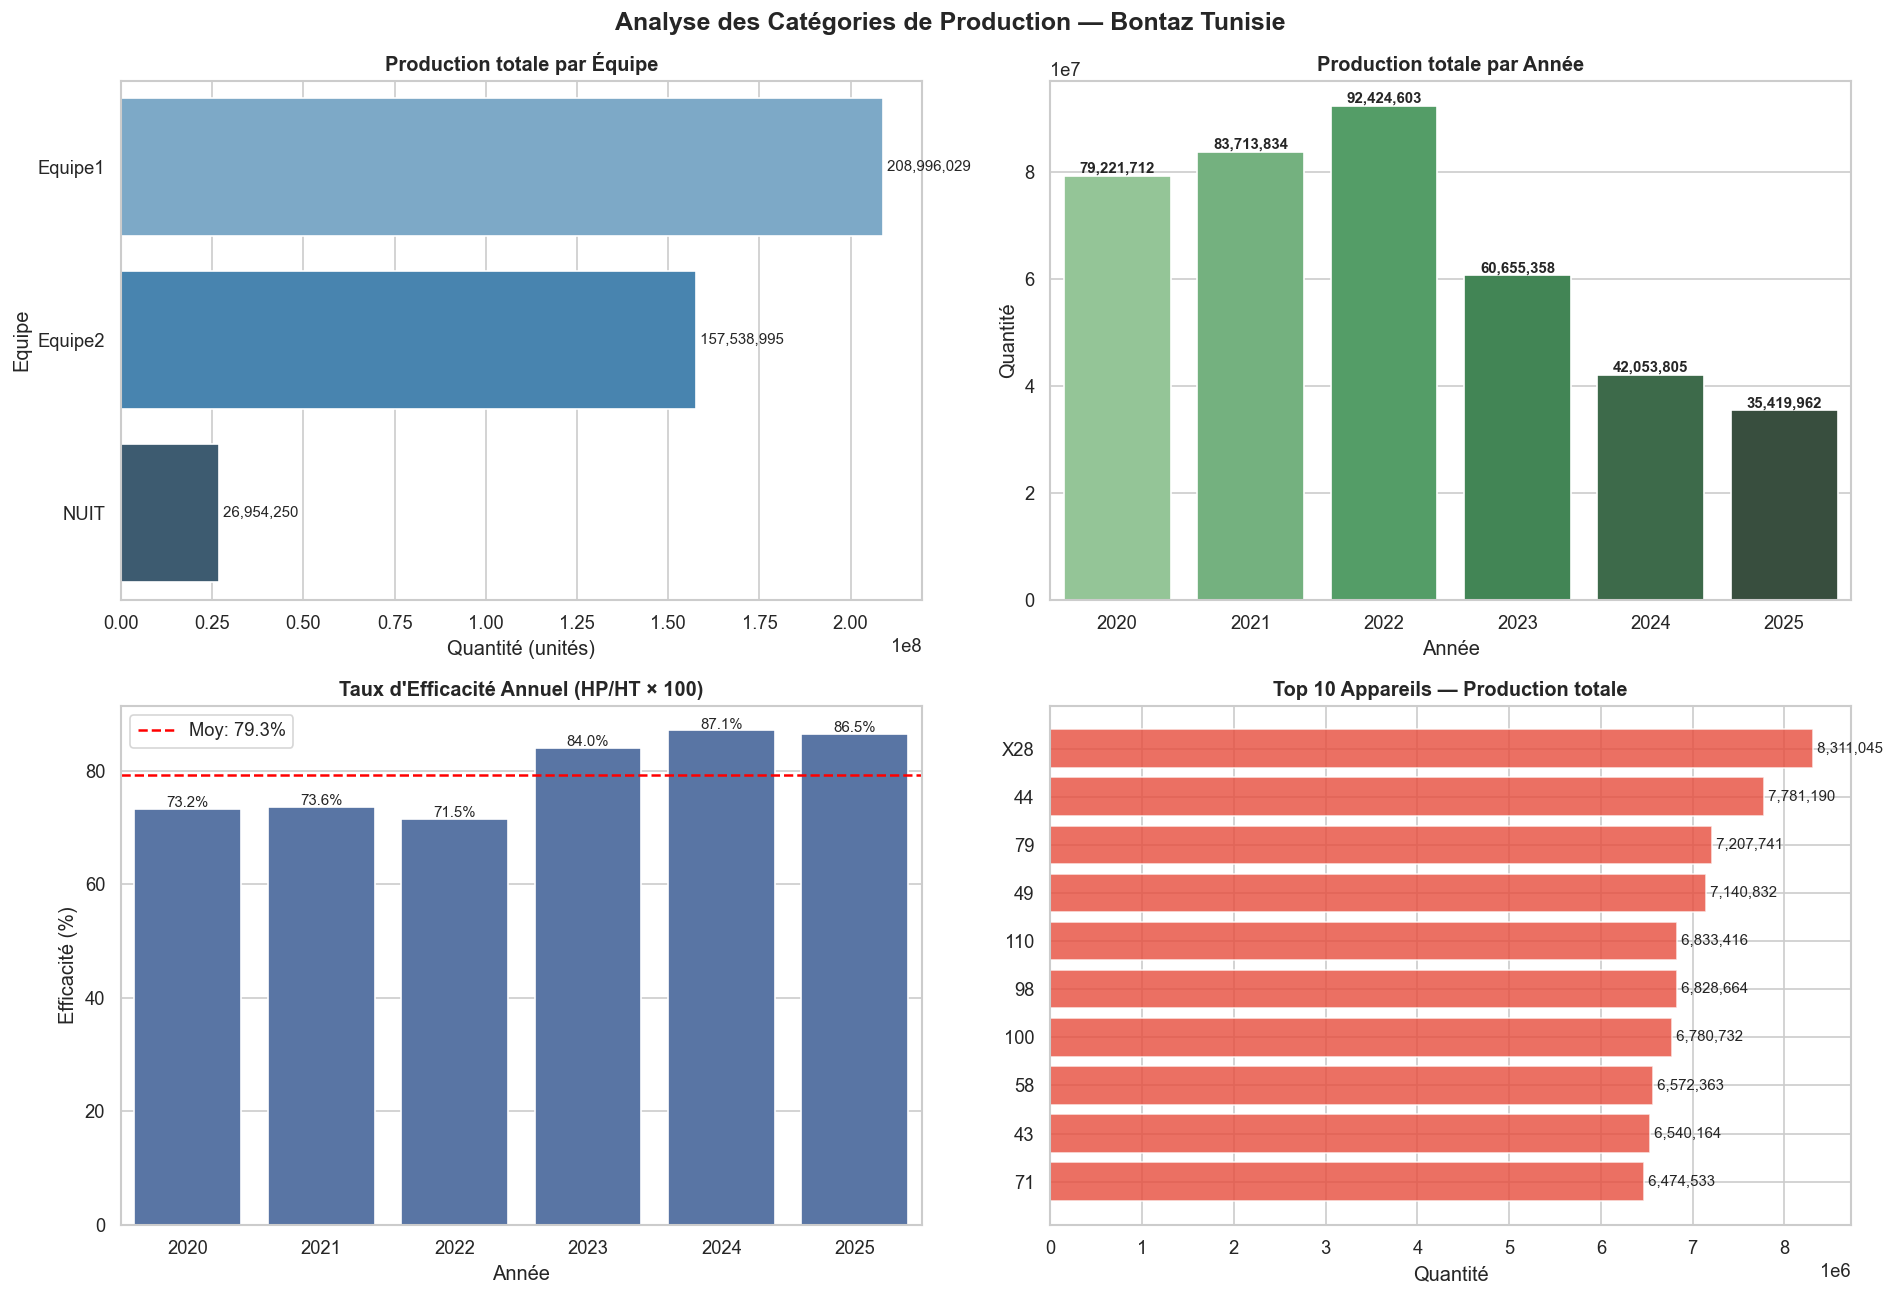


── Variables catégorielles ────────────────────────────────────────────
  Equipe               :    3 modalités distinctes
  Code Usine           :    1 modalités distinctes
  Code appareil        :   86 modalités distinctes
  Code gamme           :  333 modalités distinctes


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Analyse des Catégories de Production — Bontaz Tunisie", fontsize=15, fontweight="bold")

# 1. Production par Équipe
ax = axes[0, 0]
eq = df.groupby("Equipe")["Quantité produite"].sum().sort_values(ascending=False)
bars = sns.barplot(x=eq.values, y=eq.index, ax=ax, palette="Blues_d")
ax.set_title("Production totale par Équipe"); ax.set_xlabel("Quantité (unités)")
for i, v in enumerate(eq.values):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=9)

# 2. Production par Année
ax = axes[0, 1]
yr = df.groupby("Année")["Quantité produite"].sum()
sns.barplot(x=yr.index.astype(str), y=yr.values, ax=ax, palette="Greens_d")
ax.set_title("Production totale par Année"); ax.set_ylabel("Quantité"); ax.set_xlabel("Année")
for i, v in enumerate(yr.values):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# 3. Taux d'efficacité HP/HT par Année
ax = axes[1, 0]
eff = df.groupby("Année").apply(
    lambda g: g["Heures produites"].sum() / g["Heures travaillées"].sum() * 100
    if g["Heures travaillées"].sum() > 0 else 0).reset_index(name="Efficacité (%)")
sns.barplot(data=eff, x="Année", y="Efficacité (%)", ax=ax, color="#4C72B0")
moy = eff["Efficacité (%)"].mean()
ax.axhline(moy, color="red", ls="--", lw=1.5, label=f"Moy: {moy:.1f}%")
ax.set_title("Taux d'Efficacité Annuel (HP/HT × 100)"); ax.legend()
for i, row in eff.iterrows():
    ax.text(i, row["Efficacité (%)"]+0.3, f"{row['Efficacité (%)']:.1f}%", ha="center", fontsize=9)

# 4. Top 10 appareils par production
ax = axes[1, 1]
top10 = df.groupby("Code appareil")["Quantité produite"].sum().nlargest(10).sort_values()
ax.barh(top10.index, top10.values, color="#E74C3C", alpha=0.8)
ax.set_title("Top 10 Appareils — Production totale"); ax.set_xlabel("Quantité")
for i, (idx, v) in enumerate(top10.items()):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=9)

plt.tight_layout(); plt.show()

# Distribution des catégories
print("\n── Variables catégorielles ────────────────────────────────────────────")
for var in ["Equipe", "Code Usine", "Code appareil", "Code gamme"]:
    if var not in df.columns: continue
    s = df[var].astype(str).str.strip().replace({"nan":"","None":""})
    s = s[s != ""]
    print(f"  {var:20} : {s.nunique():4} modalités distinctes")

---
## 5. Détection & Correction des Valeurs Aberrantes
**Objectif :** identifier les outliers sur HT, HP et Quantité par méthode combinée (IQR + Z-score + MAD), puis corriger les HT aberrantes par la médiane saine du même couple (appareil, gamme) et recalculer HP et Quantité.

In [6]:
# ── Bornes IQR globales ───────────────────────────────────────────────────────
ht_s = df["Heures travaillées"].dropna()
Q1, Q3 = ht_s.quantile(0.25), ht_s.quantile(0.75)
IQR = Q3 - Q1
BORNE_INF = Q1 - 1.5 * IQR
BORNE_SUP = Q3 + 1.5 * IQR

print(f"Bornes IQR — Heures travaillées : [{BORNE_INF:.3f}h , {BORNE_SUP:.3f}h]")
print(f"  Q1={Q1:.3f}  Q3={Q3:.3f}  IQR={IQR:.3f}")

# ── Détection par 3 méthodes ──────────────────────────────────────────────────
NUM_COLS_OUT = ["Heures travaillées", "Quantité produite", "Heures produites"]
outlier_masks = {}

print("\n" + "="*70)
print("DÉTECTION DES ANOMALIES — Consensus IQR + Z-Score + MAD (≥ 2/3)")
print("="*70)

for col in NUM_COLS_OUT:
    if col not in df.columns: continue
    data   = df[col].dropna()
    filled = df[col].fillna(df[col].mean())

    Q1c,Q3c = data.quantile(0.25), data.quantile(0.75); IQRc=Q3c-Q1c
    m_iqr = (df[col]<Q1c-1.5*IQRc)|(df[col]>Q3c+1.5*IQRc)

    std = data.std(ddof=0)
    m_z = (np.abs((filled-filled.mean())/std)>3) if pd.notna(std) and std!=0           else pd.Series(False, index=df.index)

    med = data.median(); mad=np.median(np.abs(data-med))
    m_mad = (np.abs(0.6745*(filled-med)/mad)>3.5) if mad!=0             else pd.Series(False, index=df.index)

    comb = (m_iqr.astype(int)+m_z.astype(int)+m_mad.astype(int))>=2
    outlier_masks[col] = comb

    print(f"\n  {col}")
    print(f"    IQR:{m_iqr.sum():5d}  Z-Score:{m_z.sum():5d}  MAD:{m_mad.sum():5d}")
    print(f"    CONSENSUS (≥2) : {comb.sum()} ({comb.sum()/len(df)*100:.2f}%)")

# Masque global & classification
mask_ht = outlier_masks["Heures travaillées"]
mask_qty= outlier_masks["Quantité produite"]
df["est_anomalie"]   = mask_ht | mask_qty
df["type_anomalie"]  = ""
df.loc[mask_ht & ~mask_qty, "type_anomalie"] = "Heures anormales"
df.loc[~mask_ht & mask_qty, "type_anomalie"] = "Quantité anormale"
df.loc[mask_ht & mask_qty,  "type_anomalie"] = "CRITIQUE — les deux"

print(f"\n  Normal    : {(~df['est_anomalie']).sum():,}")
print(f"  Anomalies : {df['est_anomalie'].sum():,}")
print(f"    → Heures anormales       : {(df['type_anomalie']=='Heures anormales').sum()}")
print(f"    → Quantité anormale      : {(df['type_anomalie']=='Quantité anormale').sum()}")
print(f"    → CRITIQUE (les deux)    : {(df['type_anomalie']=='CRITIQUE — les deux').sum()}")

Bornes IQR — Heures travaillées : [5.500h , 9.500h]
  Q1=7.000  Q3=8.000  IQR=1.000

DÉTECTION DES ANOMALIES — Consensus IQR + Z-Score + MAD (≥ 2/3)

  Heures travaillées
    IQR:15235  Z-Score: 2510  MAD:    0
    CONSENSUS (≥2) : 2510 (2.20%)

  Quantité produite
    IQR: 1910  Z-Score:  720  MAD:  603
    CONSENSUS (≥2) : 720 (0.63%)

  Heures produites
    IQR: 1308  Z-Score:  546  MAD:  356
    CONSENSUS (≥2) : 546 (0.48%)

  Normal    : 111,149
  Anomalies : 3,110
    → Heures anormales       : 2390
    → Quantité anormale      : 600
    → CRITIQUE (les deux)    : 120


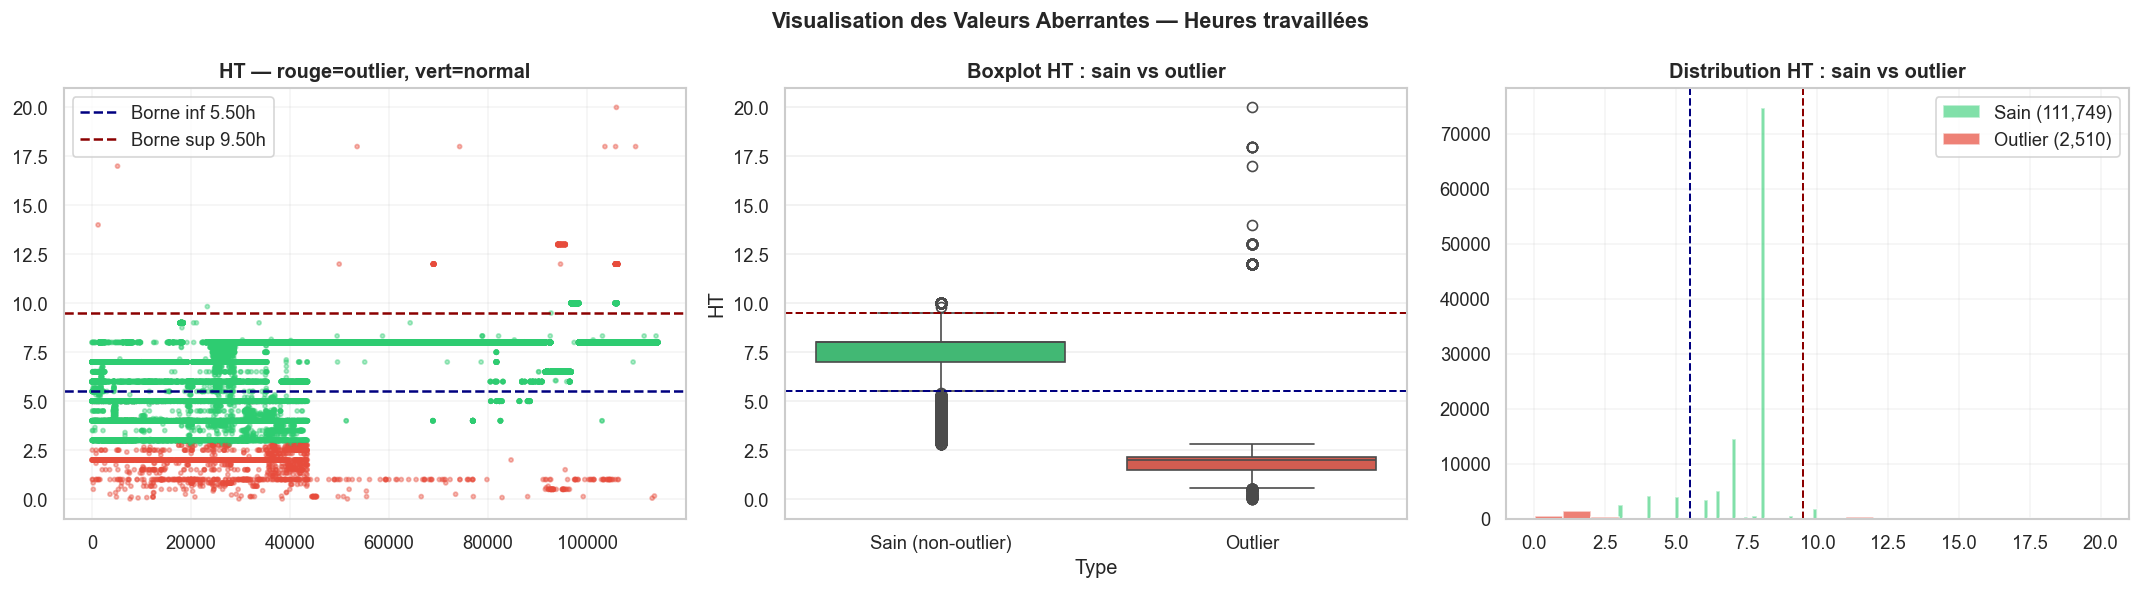


Outliers HT par Code appareil :


,nb,ht_min,ht_moy,ht_max
Code appareil,,,,
X50,171,0.080,2.292,13.000
X49,140,0.750,2.447,12.000
X58,139,0.660,1.910,2.750
X55,94,0.660,1.907,2.750
X43,83,0.050,1.868,12.000
...,...,...,...,...
26,3,0.500,1.667,2.500
122,2,1.000,6.500,12.000
126,2,1.000,1.000,1.000


In [7]:
# ── Visualisation des outliers ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Visualisation des Valeurs Aberrantes — Heures travaillées", fontweight="bold", fontsize=13)

ht = df["Heures travaillées"]
mask_out = outlier_masks["Heures travaillées"]

# Scatter toutes valeurs
axes[0].scatter(range(len(df)), ht,
    c=mask_out.map({True:"#E74C3C",False:"#2ECC71"}), s=6, alpha=0.4)
axes[0].axhline(BORNE_INF, color="navy",    ls="--", lw=1.5, label=f"Borne inf {BORNE_INF:.2f}h")
axes[0].axhline(BORNE_SUP, color="darkred", ls="--", lw=1.5, label=f"Borne sup {BORNE_SUP:.2f}h")
axes[0].set_title("HT — rouge=outlier, vert=normal"); axes[0].legend(); axes[0].grid(alpha=0.2)

# Boxplot avant/après (anticipation)
df_sain_vis = df[~mask_out]
plot_v = pd.DataFrame({"Sain (non-outlier)": df_sain_vis["Heures travaillées"],
                        "Outlier": df[mask_out]["Heures travaillées"]}).melt(
    var_name="Type", value_name="HT").dropna()
sns.boxplot(data=plot_v, x="Type", y="HT",
    hue="Type", palette={"Sain (non-outlier)":"#2ECC71","Outlier":"#E74C3C"},
    legend=False, ax=axes[1])
axes[1].axhline(BORNE_INF, color="navy",    ls="--", lw=1.2)
axes[1].axhline(BORNE_SUP, color="darkred", ls="--", lw=1.2)
axes[1].set_title("Boxplot HT : sain vs outlier"); axes[1].grid(axis="y", alpha=0.3)

# Distribution
axes[2].hist(df[~mask_out]["Heures travaillées"].dropna(), bins=50, alpha=0.6,
    color="#2ECC71", label=f"Sain ({(~mask_out).sum():,})")
axes[2].hist(df[mask_out]["Heures travaillées"].dropna(),  bins=20, alpha=0.7,
    color="#E74C3C", label=f"Outlier ({mask_out.sum():,})")
axes[2].axvline(BORNE_INF, color="navy",    ls="--", lw=1.2)
axes[2].axvline(BORNE_SUP, color="darkred", ls="--", lw=1.2)
axes[2].set_title("Distribution HT : sain vs outlier"); axes[2].legend(); axes[2].grid(alpha=0.2)

plt.tight_layout(); plt.show()

# Outliers par appareil
print("\nOutliers HT par Code appareil :")
out_app = df[mask_out].groupby("Code appareil")["Heures travaillées"].agg(
    nb="count", ht_min="min", ht_moy="mean", ht_max="max").sort_values("nb",ascending=False)
display(out_app)

CORRECTION HT PAR MÉDIANE SAINE (appareil + gamme)

Outliers corrigés : 2510
Source
app+gamme    2504
appareil        6

Détail :


,Index,App,Gamme,HT_avant,HT_apres,Type,Source
0,18,X50,1172470AATN0,2.000,5.500,trop_faible,app+gamme
1,19,X49,1172470AATN0,2.000,5.500,trop_faible,app+gamme
2,41,60,1510910AATN0,2.000,5.500,trop_faible,app+gamme
3,78,58,1950790AATN0,1.000,6.500,trop_faible,app+gamme
4,92,59,1205460AATN0,2.500,8.000,trop_faible,app+gamme
5,115,X54,1959070AATN1,2.000,5.500,trop_faible,app+gamme
6,168,X54,1959070AATN1,2.000,5.500,trop_faible,app+gamme
7,171,X48,1411830AATN1,1.000,8.000,trop_faible,app+gamme
8,178,X55,1510830AATN1,2.000,5.500,trop_faible,app+gamme
9,179,X54,1959070AATN1,2.000,5.500,trop_faible,app+gamme


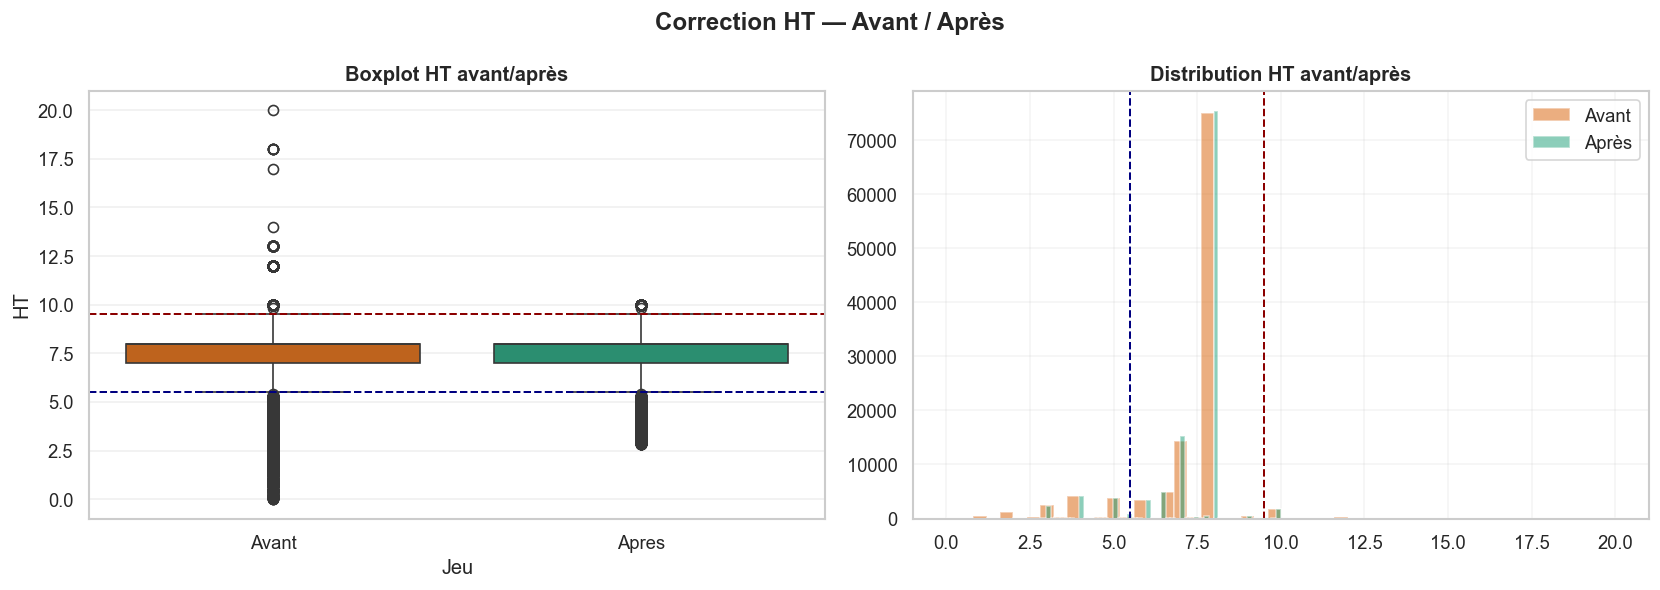


KPI comparatif :


,Jeu,Outliers IQR,HT total,HP total,Qty totale,Productivite Q/HP,Efficacite HP/HT%
0,Avant correction,15235,"833,304.010","640,540.570",393489274,614.308,76.870
1,Après correction,12725,"842,776.440","646,440.730",397456936,614.839,76.700



df mis à jour avec les données corrigées.


In [8]:
# ── Correction par médiane saine (appareil + gamme) ──────────────────────────
print("="*70)
print("CORRECTION HT PAR MÉDIANE SAINE (appareil + gamme)")
print("="*70)

df_sain  = df[~mask_out].copy()
med_ag   = df_sain.groupby(["Code appareil","Code gamme"])["Heures travaillées"].median().to_dict()
med_app  = df_sain.groupby("Code appareil")["Heures travaillées"].median().to_dict()
med_gam  = df_sain.groupby("Code gamme")["Heures travaillées"].median().to_dict()
med_glob = float(df_sain["Heures travaillées"].median())

def get_med(app, gam):
    k = (app, gam)
    if k in med_ag:   return med_ag[k],   "app+gamme"
    if app in med_app: return med_app[app],"appareil"
    if gam in med_gam: return med_gam[gam],"gamme"
    return med_glob, "global"

# Ratio HP/HT et temps unitaire sur données saines
valid_r = (df_sain["Heures travaillées"]>0) & df_sain["Heures produites"].notna()
df_sain.loc[valid_r,"r_hp_ht"] = df_sain.loc[valid_r,"Heures produites"]/df_sain.loc[valid_r,"Heures travaillées"]
ratio_ag  = df_sain.groupby(["Code appareil","Code gamme"])["r_hp_ht"].median().to_dict()
ratio_app = df_sain.groupby("Code appareil")["r_hp_ht"].median().to_dict()
ratio_g   = float(df_sain["r_hp_ht"].median())

valid_tu = (df_sain["Heures produites"]>0)&(df_sain["Quantité produite"]>0)
df_sain.loc[valid_tu,"TU"] = df_sain.loc[valid_tu,"Heures produites"]/df_sain.loc[valid_tu,"Quantité produite"]
df_sain = df_sain[np.isfinite(df_sain.get("TU", pd.Series(np.nan,index=df_sain.index)))]
tu_ag  = df_sain.groupby(["Code appareil","Code gamme"])["TU"].median().to_dict()
tu_app = df_sain.groupby("Code appareil")["TU"].median().to_dict()
tu_g   = float(df_sain["TU"].dropna().median())

def get_ratio(app,gam): return ratio_ag.get((app,gam), ratio_app.get(app, ratio_g))
def get_tu(app,gam):    return tu_ag.get((app,gam),    tu_app.get(app,    tu_g))

# Application
df_corr = df.copy()
log = []
for idx in df.index[mask_out]:
    row  = df.loc[idx]
    app,gam = row["Code appareil"], row["Code gamme"]
    ht_av   = float(row["Heures travaillées"])
    cible, src = get_med(app, gam)
    cible = float(np.clip(cible, BORNE_INF, BORNE_SUP))
    df_corr.at[idx,"Heures travaillées"] = round(cible, 4)
    r  = get_ratio(app, gam)
    tu = get_tu(app, gam)
    hp_n = max(0.0, cible * r)
    q_n  = round(max(0.0, hp_n/tu), 0) if tu > 0 else np.nan
    df_corr.at[idx,"Heures produites"]  = round(hp_n, 4)
    df_corr.at[idx,"Quantité produite"] = q_n
    df_corr.at[idx,"Heures_Perte"] = max(0.0, round(cible-hp_n, 4))
    log.append({"Index":idx, "App":app, "Gamme":gam,
                "HT_avant":round(ht_av,3), "HT_apres":round(cible,4),
                "Type":"trop_eleve" if ht_av>BORNE_SUP else "trop_faible", "Source":src})

log_df = pd.DataFrame(log)
print(f"\nOutliers corrigés : {len(log_df)}")
print(log_df["Source"].value_counts().to_string())
print("\nDétail :"); display(log_df.head(20))

# Boxplot avant/après
fig,axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle("Correction HT — Avant / Après",fontweight="bold")
plot_c = pd.DataFrame({"Avant":df["Heures travaillées"],"Apres":df_corr["Heures travaillées"]}).melt(
    var_name="Jeu",value_name="HT").dropna()
sns.boxplot(data=plot_c,x="Jeu",y="HT",hue="Jeu",
    palette=["#d95f02","#1b9e77"],legend=False,ax=axes[0])
axes[0].axhline(BORNE_INF,color="navy",ls="--",lw=1.2)
axes[0].axhline(BORNE_SUP,color="darkred",ls="--",lw=1.2)
axes[0].set_title("Boxplot HT avant/après"); axes[0].grid(axis="y",alpha=0.3)
axes[1].hist(df["Heures travaillées"].dropna(),bins=50,alpha=0.5,color="#d95f02",label="Avant")
axes[1].hist(df_corr["Heures travaillées"].dropna(),bins=50,alpha=0.5,color="#1b9e77",label="Après")
axes[1].axvline(BORNE_INF,color="navy",ls="--",lw=1.2)
axes[1].axvline(BORNE_SUP,color="darkred",ls="--",lw=1.2)
axes[1].legend(); axes[1].set_title("Distribution HT avant/après"); axes[1].grid(alpha=0.2)
plt.tight_layout(); plt.show()

# KPI comparatif
def kpi(d,label):
    ht_=d["Heures travaillées"]; hp_=d["Heures produites"]; q_=d["Quantité produite"]
    s,p,q=ht_.sum(),hp_.sum(),q_.sum()
    return {"Jeu":label,"Outliers IQR":int(((ht_<BORNE_INF)|(ht_>BORNE_SUP)).sum()),
            "HT total":round(s,2),"HP total":round(p,2),"Qty totale":round(q,0),
            "Productivite Q/HP":round(q/p,3) if p else np.nan,
            "Efficacite HP/HT%":round(p/s*100,2) if s else np.nan}

print("\nKPI comparatif :")
display(pd.DataFrame([kpi(df,"Avant correction"),kpi(df_corr,"Après correction")]))

# Utiliser df_corr comme référence désormais
df = df_corr.copy()
print("\ndf mis à jour avec les données corrigées.")

---
## 6. Matrice de Corrélation
**Objectif :** mesurer les relations linéaires entre HT, HP et Quantité produite et visualiser les paires fortement corrélées.

Matrice de corrélation :
0                   Heures travaillées  Quantité produite  Heures produites
0                                                                          
Heures travaillées               1.000              0.379             0.399
Quantité produite                0.379              1.000             0.880
Heures produites                 0.399              0.880             1.000


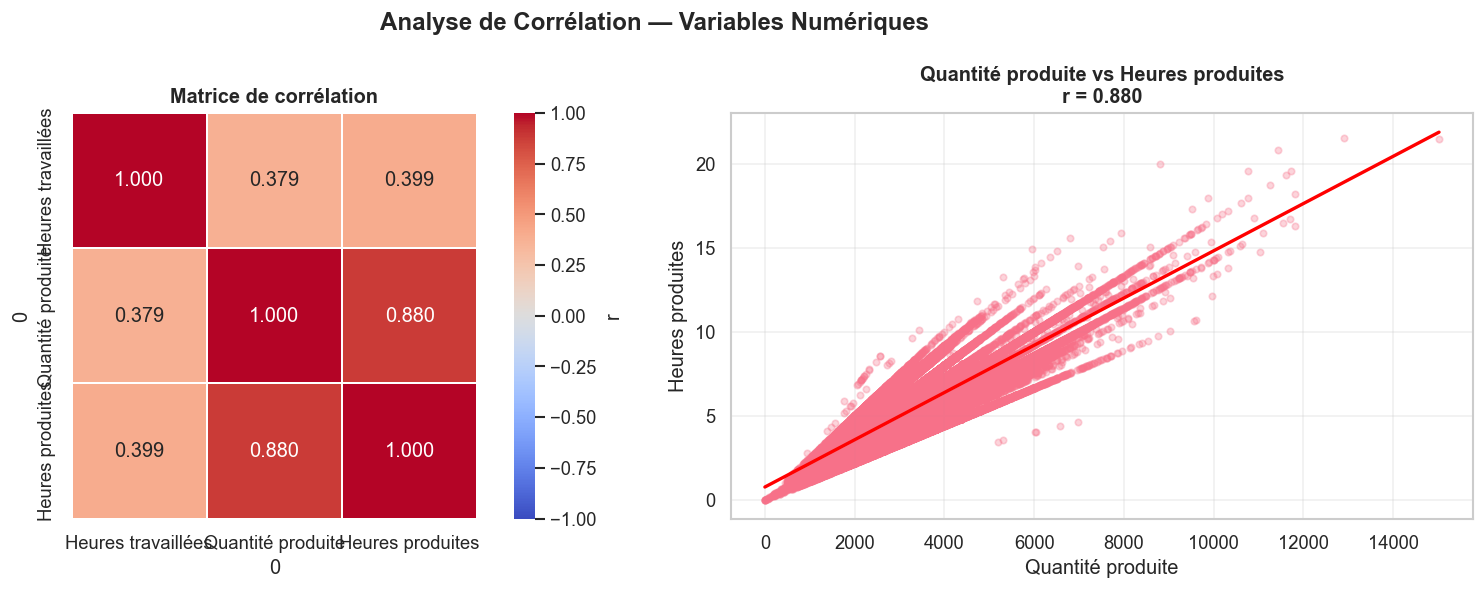

In [9]:
cm = df[["Heures travaillées","Quantité produite","Heures produites"]].corr()
print("Matrice de corrélation :"); print(cm.round(3))

fig,axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle("Analyse de Corrélation — Variables Numériques",fontweight="bold")

sns.heatmap(cm,annot=True,fmt=".3f",cmap="coolwarm",center=0,square=True,
    linewidths=1,cbar_kws={"label":"r"},vmin=-1,vmax=1,ax=axes[0])
axes[0].set_title("Matrice de corrélation")

# Scatter paires fortes
paires = [(c1,c2,cm.loc[c1,c2]) for i,c1 in enumerate(cm.columns)
          for j,c2 in enumerate(cm.columns) if j>i and abs(cm.loc[c1,c2])>0.5]
if paires:
    c1,c2,r = sorted(paires,key=lambda x:abs(x[2]),reverse=True)[0]
    p = df[[c1,c2]].apply(pd.to_numeric,errors="coerce").dropna()
    sns.regplot(data=p,x=c1,y=c2,
        scatter_kws={"alpha":0.3,"s":15},line_kws={"color":"red","lw":2},ax=axes[1])
    axes[1].set_title(f"{c1} vs {c2}\nr = {r:.3f}"); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
correlation_matrix = cm

---
## 7. KPI Globaux de Synthèse
**Objectif :** calculer les indicateurs de haut niveau sur l'ensemble de la période 2020–2025.

In [10]:
ht_tot  = df["Heures travaillées"].sum()
hp_tot  = df["Heures produites"].sum()
qty_tot = df["Quantité produite"].sum()
perte_tot= max(0, ht_tot-hp_tot)

print("="*60)
print("KPI GLOBAUX — BONTAZ TUNISIE (2020–2025)")
print("="*60)
print(f"  Production totale (unités)    : {qty_tot:>15,.0f}")
print(f"  Heures travaillées totales    : {ht_tot:>15,.2f} h")
print(f"  Heures produites totales      : {hp_tot:>15,.2f} h")
print(f"  Heures de perte (HT-HP)       : {perte_tot:>15,.2f} h  ({perte_tot/ht_tot*100:.2f}%)")
print(f"  Efficacité HP/HT              : {hp_tot/ht_tot*100:>15,.2f} %")
print(f"  Productivité (u/HP)           : {qty_tot/hp_tot:>15,.3f} u/h")
print(f"  Productivité brute (u/HT)     : {qty_tot/ht_tot:>15,.3f} u/h")
print(f"  Machine la plus utilisée      : {df['Code appareil'].value_counts().index[0]}")
print(f"  Gamme la plus produite        : {df.groupby('Code gamme')['Quantité produite'].sum().idxmax()}")
print(f"  Équipe la plus productive     : {df.groupby('Equipe')['Quantité produite'].sum().idxmax()}")
print("="*60)

KPI GLOBAUX — BONTAZ TUNISIE (2020–2025)
  Production totale (unités)    :     397,456,936
  Heures travaillées totales    :      842,776.45 h
  Heures produites totales      :      646,440.73 h
  Heures de perte (HT-HP)       :      196,335.71 h  (23.30%)
  Efficacité HP/HT              :           76.70 %
  Productivité (u/HP)           :         614.839 u/h
  Productivité brute (u/HT)     :         471.604 u/h
  Machine la plus utilisée      : 79
  Gamme la plus produite        : 1653240AATN0
  Équipe la plus productive     : Equipe1


---
## 8. Analyse Temporelle Complète
**Objectif :** analyser l'évolution de la production par année, mois et jour, et calculer les KPI temporels (efficacité, taux de perte, productivité) à chaque granularité.

PRODUCTION ANNUELLE :
 Année  Quantité          HT          HP  Efficacité  Productivité_HT  Productivité_HP  Taux_Perte_%
  2020  78512238 166,918.580 121,868.433      73.010          470.362          644.238        26.990
  2021  83799491 176,441.860 129,766.834      73.550          474.941          645.770        26.450
  2022  92481387 217,792.160 155,680.400      71.480          424.631          594.046        28.520
  2023  62867731 128,807.695 107,237.263      83.250          488.074          586.249        16.750
  2024  43500723  84,004.390  72,653.718      86.490          517.839          598.740        13.510
  2025  36295366  68,811.760  59,234.083      86.080          527.459          612.745        13.920


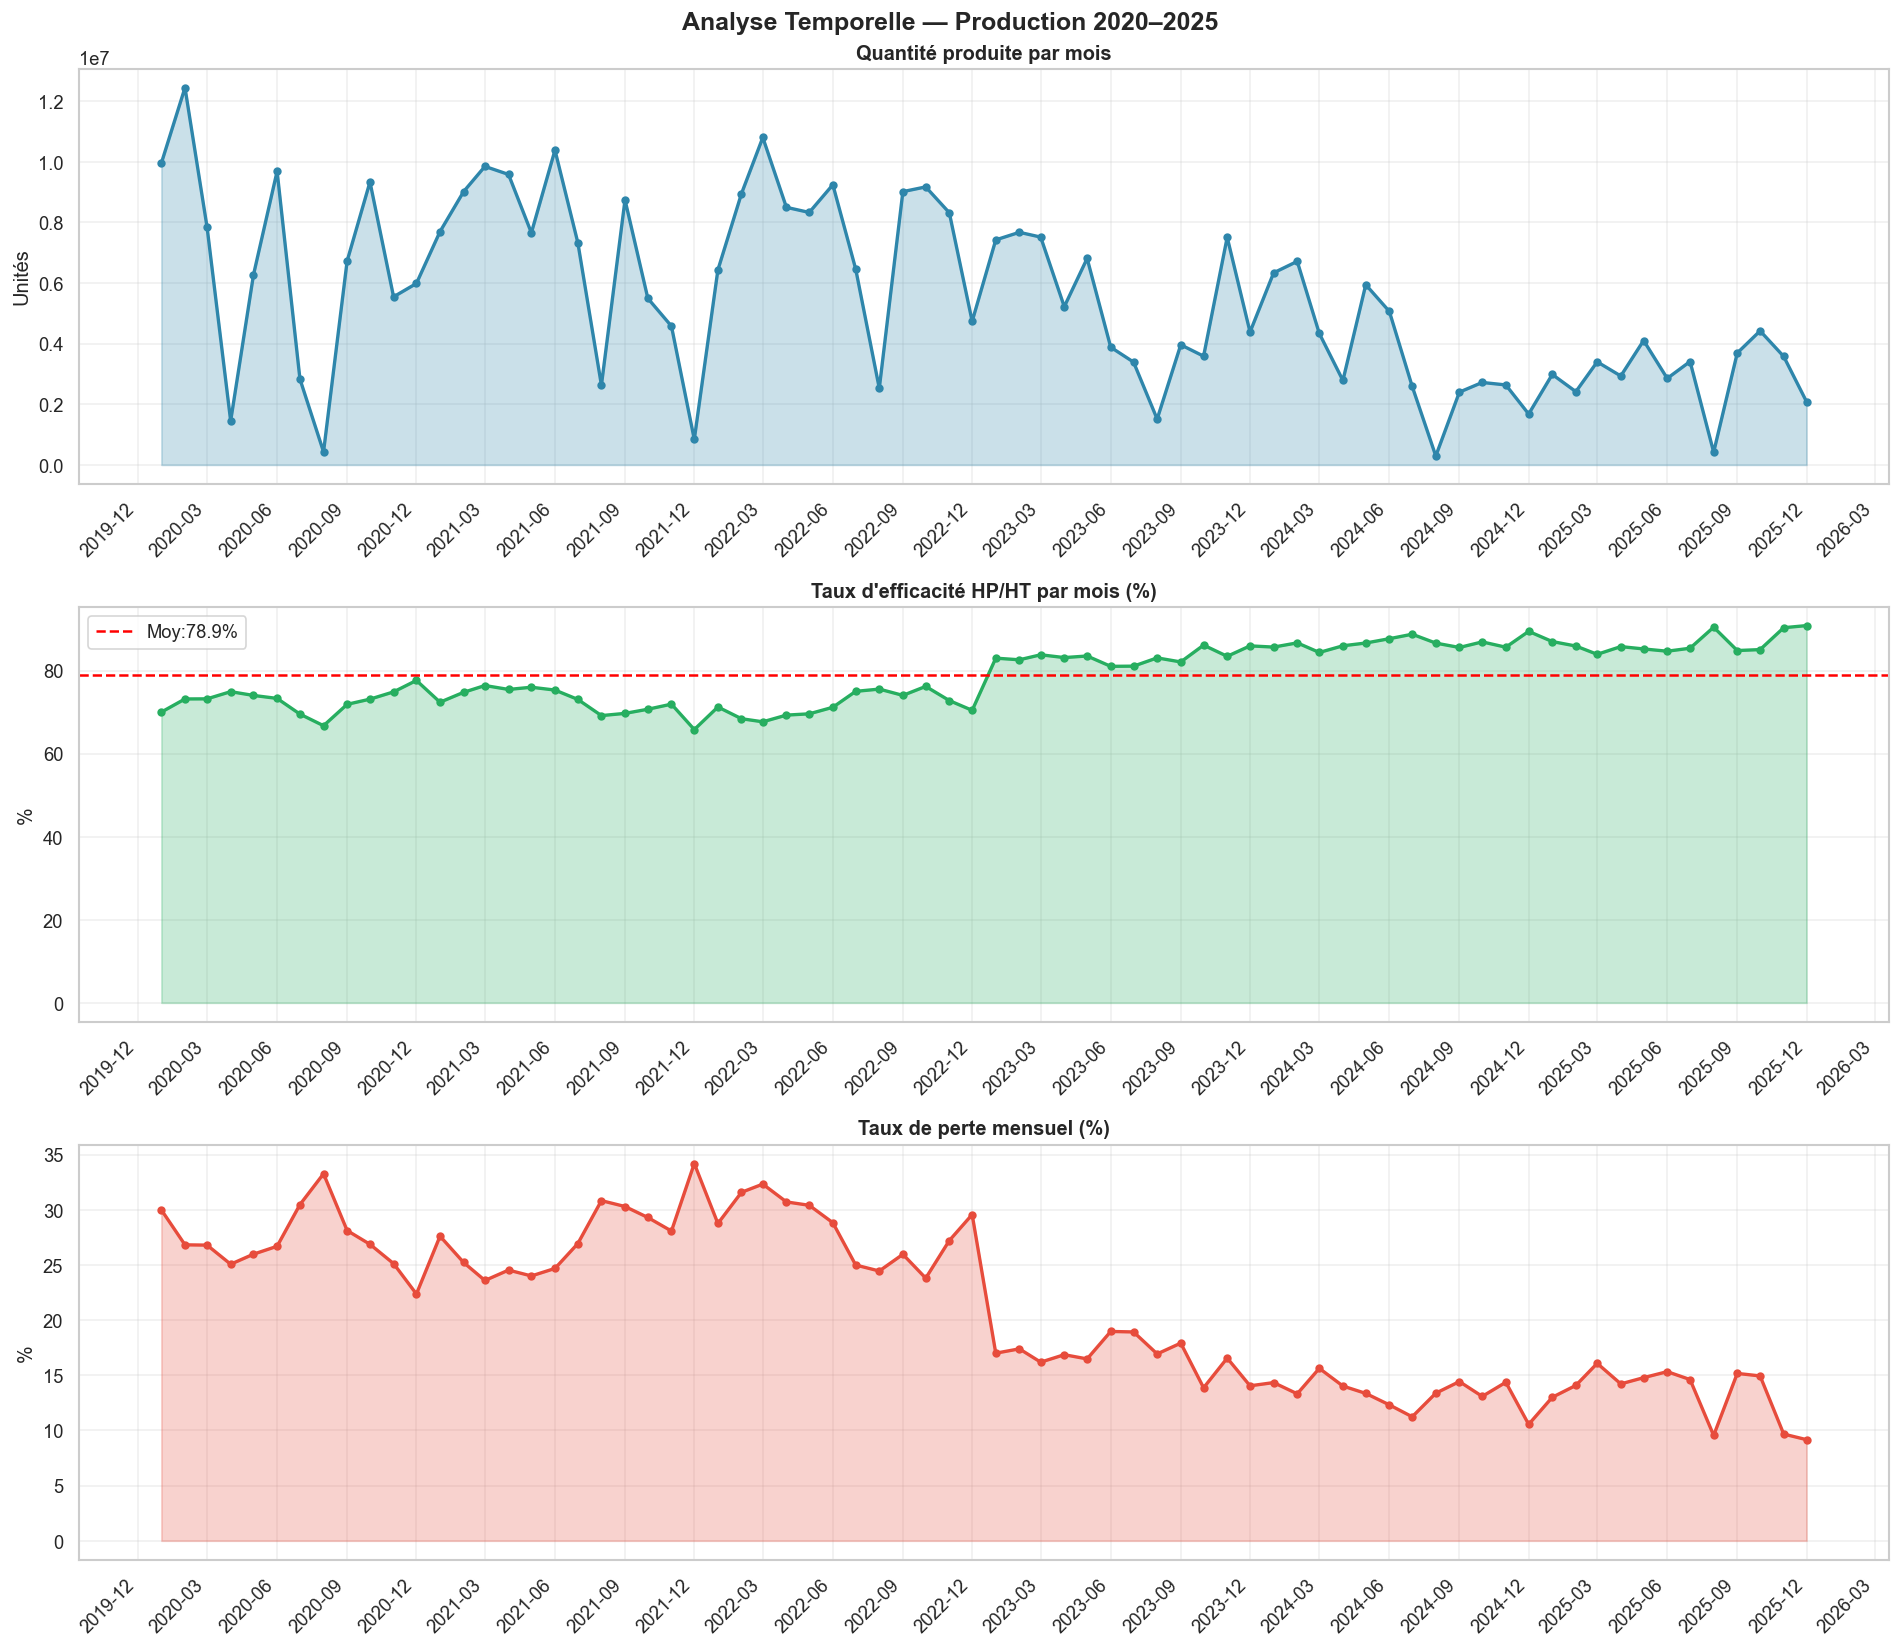

In [11]:
# Agrégations
monthly = df.groupby("Année_Mois").agg(
    Quantité=("Quantité produite","sum"),
    HT=("Heures travaillées","sum"),
    HP=("Heures produites","sum"),
    Jours=("Date_Jour","nunique")
).reset_index()
monthly["Date"]        = pd.to_datetime(monthly["Année_Mois"])
monthly["Efficacité"]  = monthly["HP"]/monthly["HT"]*100
monthly["Productivité"]= monthly["Quantité"]/monthly["HP"]
monthly["Taux_Perte"]  = (monthly["HT"]-monthly["HP"])/monthly["HT"]*100
monthly = monthly.sort_values("Date").reset_index(drop=True)

yearly = df.groupby("Année").agg(
    Quantité=("Quantité produite","sum"),
    HT=("Heures travaillées","sum"),
    HP=("Heures produites","sum")
).reset_index()
yearly["Efficacité"]      = (yearly["HP"]/yearly["HT"]*100).round(2)
yearly["Productivité_HT"] = (yearly["Quantité"]/yearly["HT"]).round(3)
yearly["Productivité_HP"] = (yearly["Quantité"]/yearly["HP"]).round(3)
yearly["Taux_Perte_%"]    = ((yearly["HT"]-yearly["HP"])/yearly["HT"]*100).round(2)

print("PRODUCTION ANNUELLE :")
print(yearly.to_string(index=False))

# Visualisation 3 graphes
fig, axes = plt.subplots(3,1,figsize=(16,14))
fig.suptitle("Analyse Temporelle — Production 2020–2025",fontsize=15,fontweight="bold")

ax=axes[0]
ax.fill_between(monthly["Date"],monthly["Quantité"],alpha=0.25,color="#2E86AB")
ax.plot(monthly["Date"],monthly["Quantité"],"-o",lw=2,ms=4,color="#2E86AB")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_title("Quantité produite par mois"); ax.set_ylabel("Unités")
plt.setp(ax.get_xticklabels(),rotation=45,ha="right"); ax.grid(alpha=0.3)

ax=axes[1]
ax.fill_between(monthly["Date"],monthly["Efficacité"],alpha=0.25,color="#27AE60")
ax.plot(monthly["Date"],monthly["Efficacité"],"-o",lw=2,ms=4,color="#27AE60")
ax.axhline(monthly["Efficacité"].mean(),color="red",ls="--",lw=1.5,label=f"Moy:{monthly['Efficacité'].mean():.1f}%")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_title("Taux d'efficacité HP/HT par mois (%)"); ax.set_ylabel("%"); ax.legend()
plt.setp(ax.get_xticklabels(),rotation=45,ha="right"); ax.grid(alpha=0.3)

ax=axes[2]
ax.fill_between(monthly["Date"],monthly["Taux_Perte"],alpha=0.25,color="#E74C3C")
ax.plot(monthly["Date"],monthly["Taux_Perte"],"-o",lw=2,ms=4,color="#E74C3C")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_title("Taux de perte mensuel (%)"); ax.set_ylabel("%")
plt.setp(ax.get_xticklabels(),rotation=45,ha="right"); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

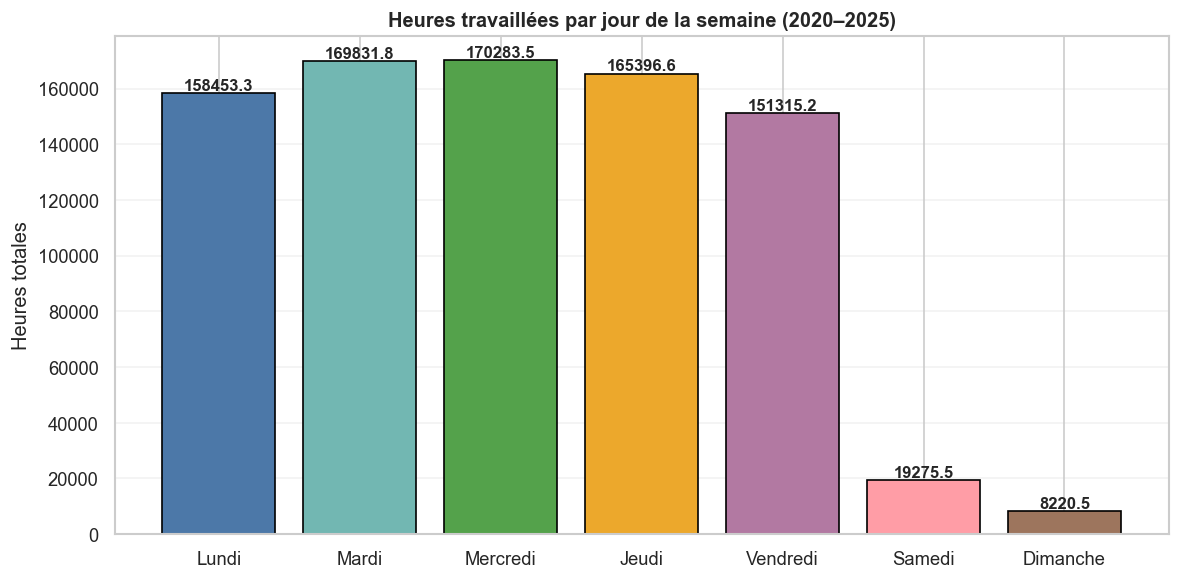

,Heures travaillées
Lundi,"158,453.255"
Mardi,"169,831.815"
Mercredi,"170,283.515"
Jeudi,"165,396.575"
Vendredi,"151,315.195"
Samedi,"19,275.550"
Dimanche,"8,220.540"


In [12]:
# Heures travaillées par jour de la semaine
mask_p = df["Date de production"].dt.year.between(2020,2025)
dfp = df.loc[mask_p].copy()
ht_num = pd.to_numeric(dfp["Heures travaillées"],errors="coerce").fillna(0)
hj = pd.Series(ht_num.values, index=dfp["Date de production"].dt.weekday).groupby(level=0).sum()
hj = hj.reindex(range(7),fill_value=0)
hj.index=["Lundi","Mardi","Mercredi","Jeudi","Vendredi","Samedi","Dimanche"]

plt.figure(figsize=(10,5))
colors_j=["#4C78A8","#72B7B2","#54A24B","#ECA82C","#B279A2","#FF9DA6","#9D755D"]
bars=plt.bar(hj.index,hj.values,color=colors_j,edgecolor="black",lw=1)
for b,v in zip(bars,hj.values):
    plt.text(b.get_x()+b.get_width()/2,b.get_height(),f"{v:.1f}",
        ha="center",va="bottom",fontsize=10,fontweight="bold")
plt.title("Heures travaillées par jour de la semaine (2020–2025)",fontweight="bold")
plt.ylabel("Heures totales"); plt.grid(axis="y",alpha=0.25)
plt.tight_layout(); plt.show()
display(hj.rename("Heures travaillées").to_frame())

---
## 9. Analyse de la Saisonnalité
**Objectif :** visualiser les patterns saisonniers — profil mensuel moyen, heatmap Année×Mois, pic annuel et récurrence.

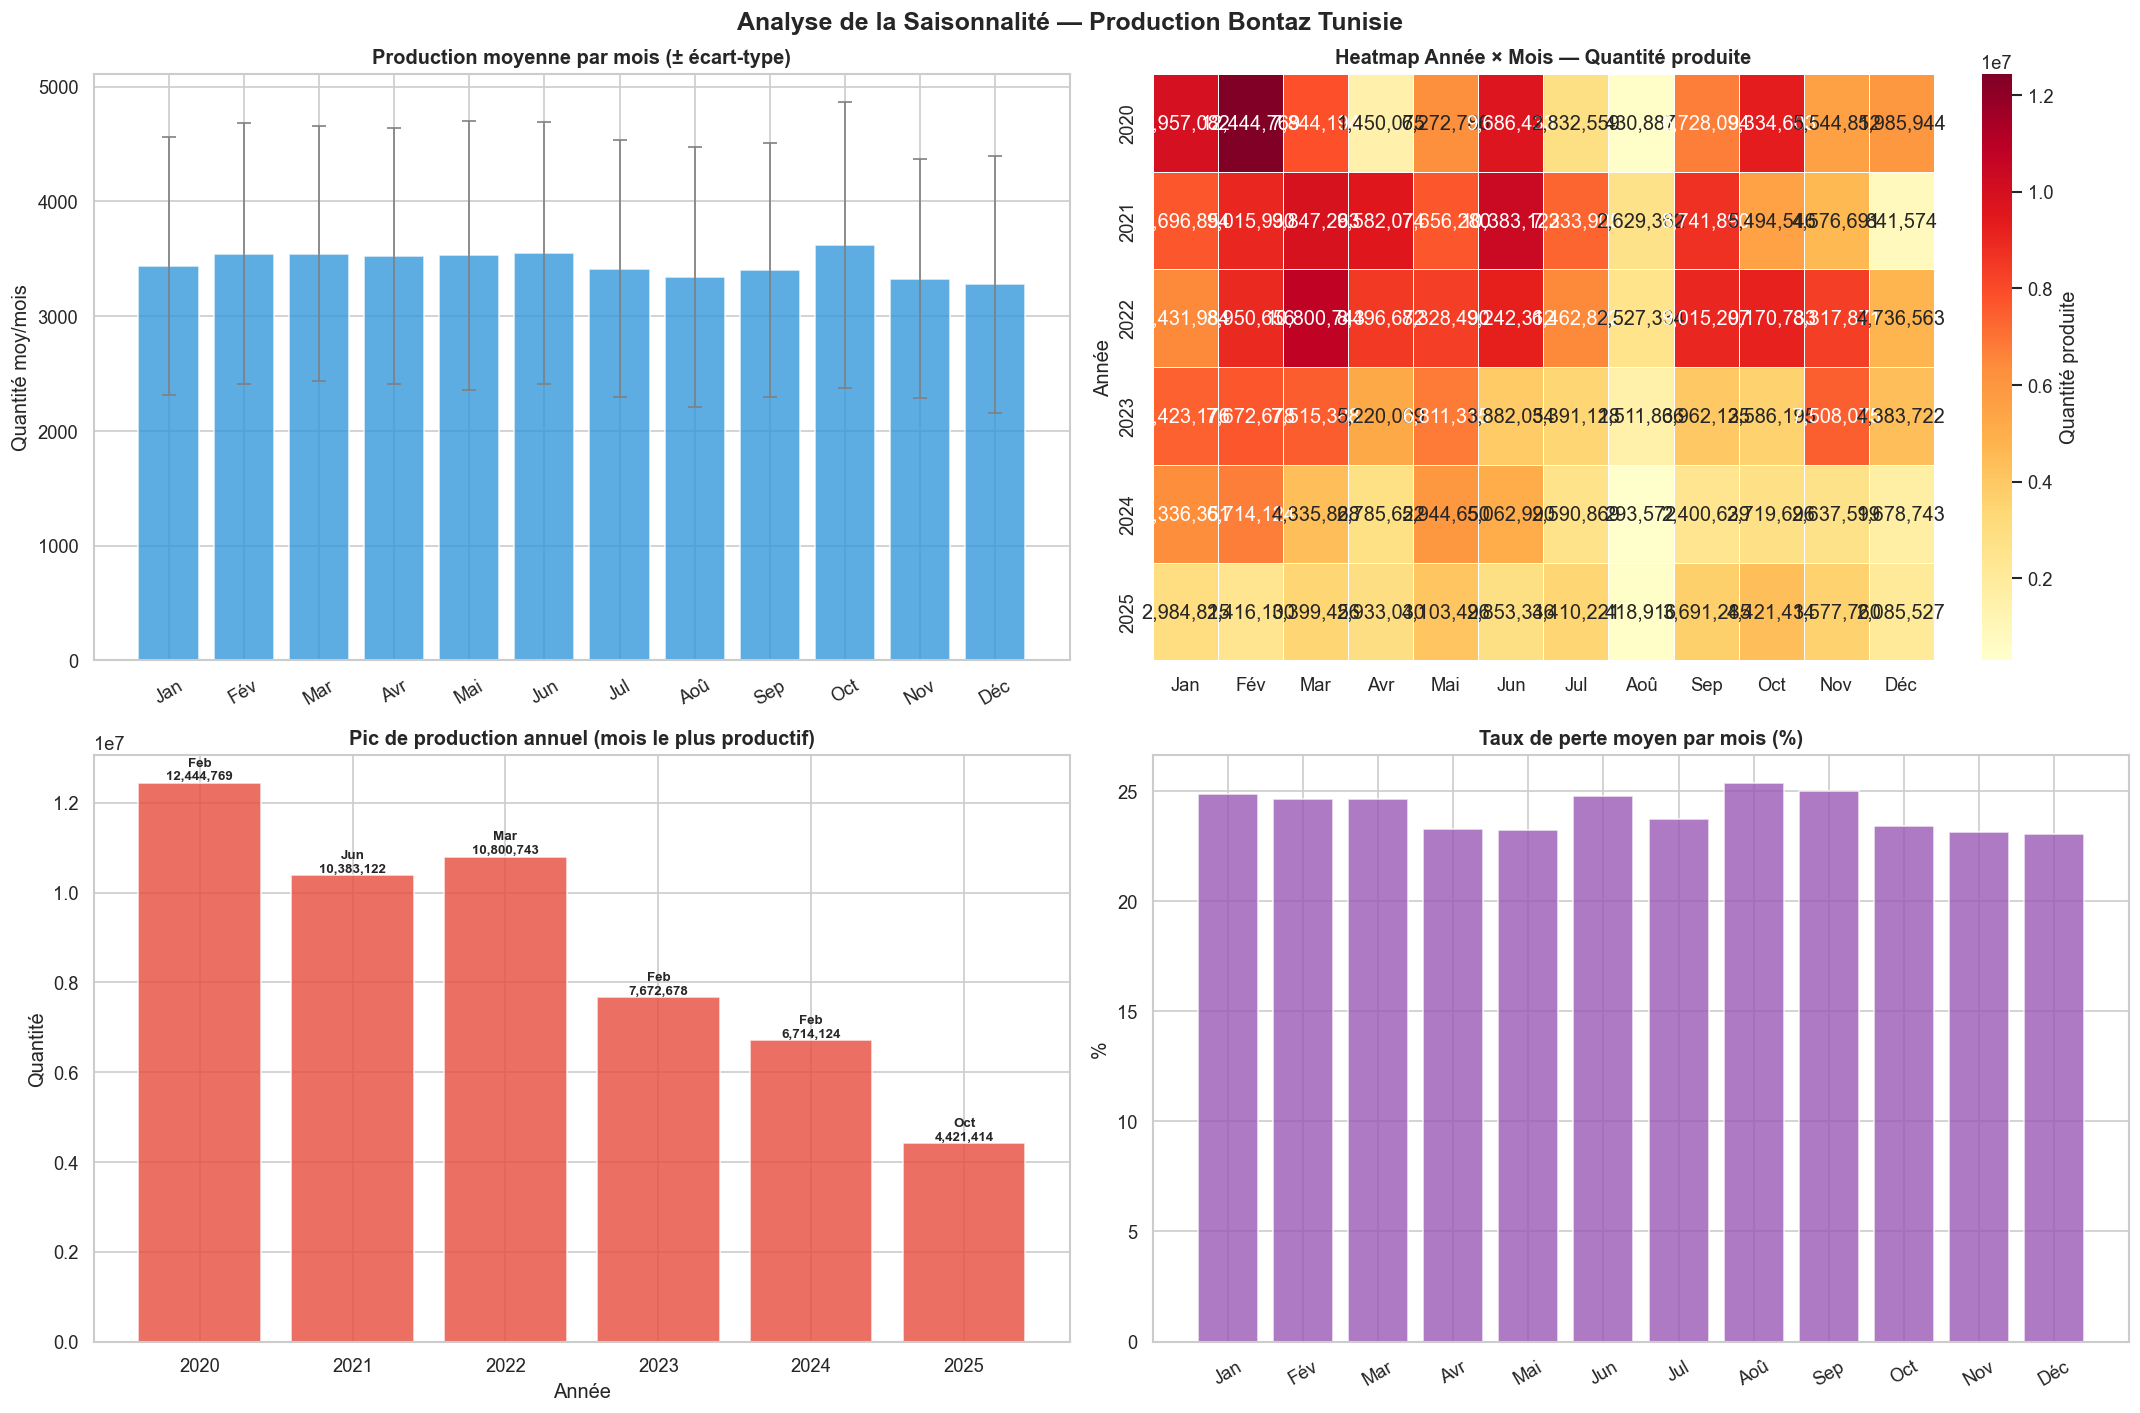


Pics de production par année :


,Année,Mois,Mois_Nom,Quantité produite
1,2020,2,February,12444769
17,2021,6,June,10383122
26,2022,3,March,10800743
37,2023,2,February,7672678
49,2024,2,February,6714124
69,2025,10,October,4421414



Mois dominant : February — 3/6 années (50.0%)


In [13]:
MOIS_ENG=["January","February","March","April","May","June",
           "July","August","September","October","November","December"]
MOIS_FR=["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]

profil = df.groupby("Mois_Nom")["Quantité produite"].agg(["mean","std","sum"])
profil = profil.reindex(MOIS_ENG); profil.index=MOIS_FR

pivot = df.groupby(["Année","Mois"])["Quantité produite"].sum().unstack(fill_value=0)
pivot.columns = MOIS_FR[:len(pivot.columns)]

pic_yr = df.groupby(["Année","Mois","Mois_Nom"])["Quantité produite"].sum().reset_index()
pic_yr = pic_yr.loc[pic_yr.groupby("Année")["Quantité produite"].idxmax()]

fig, axes = plt.subplots(2,2,figsize=(18,12))
fig.suptitle("Analyse de la Saisonnalité — Production Bontaz Tunisie",fontsize=15,fontweight="bold")

# Profil mensuel
ax=axes[0,0]
bars=ax.bar(MOIS_FR,profil["mean"],color="#3498DB",alpha=0.8,
            yerr=profil["std"],capsize=4,error_kw={"ecolor":"gray","lw":1})
ax.set_title("Production moyenne par mois (± écart-type)"); ax.set_ylabel("Quantité moy/mois")
ax.tick_params(axis="x",rotation=30)

# Heatmap
ax=axes[0,1]
sns.heatmap(pivot,annot=True,fmt=",d",cmap="YlOrRd",ax=ax,
    linewidths=0.5,cbar_kws={"label":"Quantité produite"})
ax.set_title("Heatmap Année × Mois — Quantité produite"); ax.set_ylabel("Année")

# Pic annuel
ax=axes[1,0]
ax.bar(pic_yr["Année"].astype(str),pic_yr["Quantité produite"],color="#E74C3C",alpha=0.8)
ax.set_title("Pic de production annuel (mois le plus productif)")
ax.set_ylabel("Quantité"); ax.set_xlabel("Année")
for i,row in pic_yr.reset_index(drop=True).iterrows():
    ax.text(i,row["Quantité produite"],f"{row['Mois_Nom'][:3]}\n{row['Quantité produite']:,.0f}",
        ha="center",va="bottom",fontsize=8,fontweight="bold")

# Taux perte mensuel (boxplot par mois)
ax=axes[1,1]
df_tp = df.copy()
df_tp["Mois_Nom_fr"] = df_tp["Mois"].map(dict(zip(range(1,13),MOIS_FR)))
df_tp["Taux_Perte_L"] = np.where(df_tp["Heures travaillées"]>0,
    df_tp["Heures_Perte"]/df_tp["Heures travaillées"]*100, np.nan)
tp_m = df_tp.groupby("Mois_Nom_fr")["Taux_Perte_L"].mean().reindex(MOIS_FR)
ax.bar(tp_m.index,tp_m.values,color="#9B59B6",alpha=0.8)
ax.set_title("Taux de perte moyen par mois (%)"); ax.set_ylabel("%")
ax.tick_params(axis="x",rotation=30)

plt.tight_layout(); plt.show()

# Récurrence du pic
freq=pic_yr["Mois_Nom"].value_counts()
dom,nb,tot=freq.index[0],int(freq.iloc[0]),pic_yr["Année"].nunique()
print(f"\nPics de production par année :")
display(pic_yr[["Année","Mois","Mois_Nom","Quantité produite"]])
print(f"\nMois dominant : {dom} — {nb}/{tot} années ({nb/tot*100:.1f}%)")

---
## 10. Calendrier Journalier & Jours Fériés Récurrents
**Objectif :** construire le calendrier binaire travail/arrêt et identifier les jours sans travail qui se répètent chaque année (hors week-ends, août, fin d'année).

Jours calendrier : 2192  |  Travaillés : 1457  |  Arrêts : 735


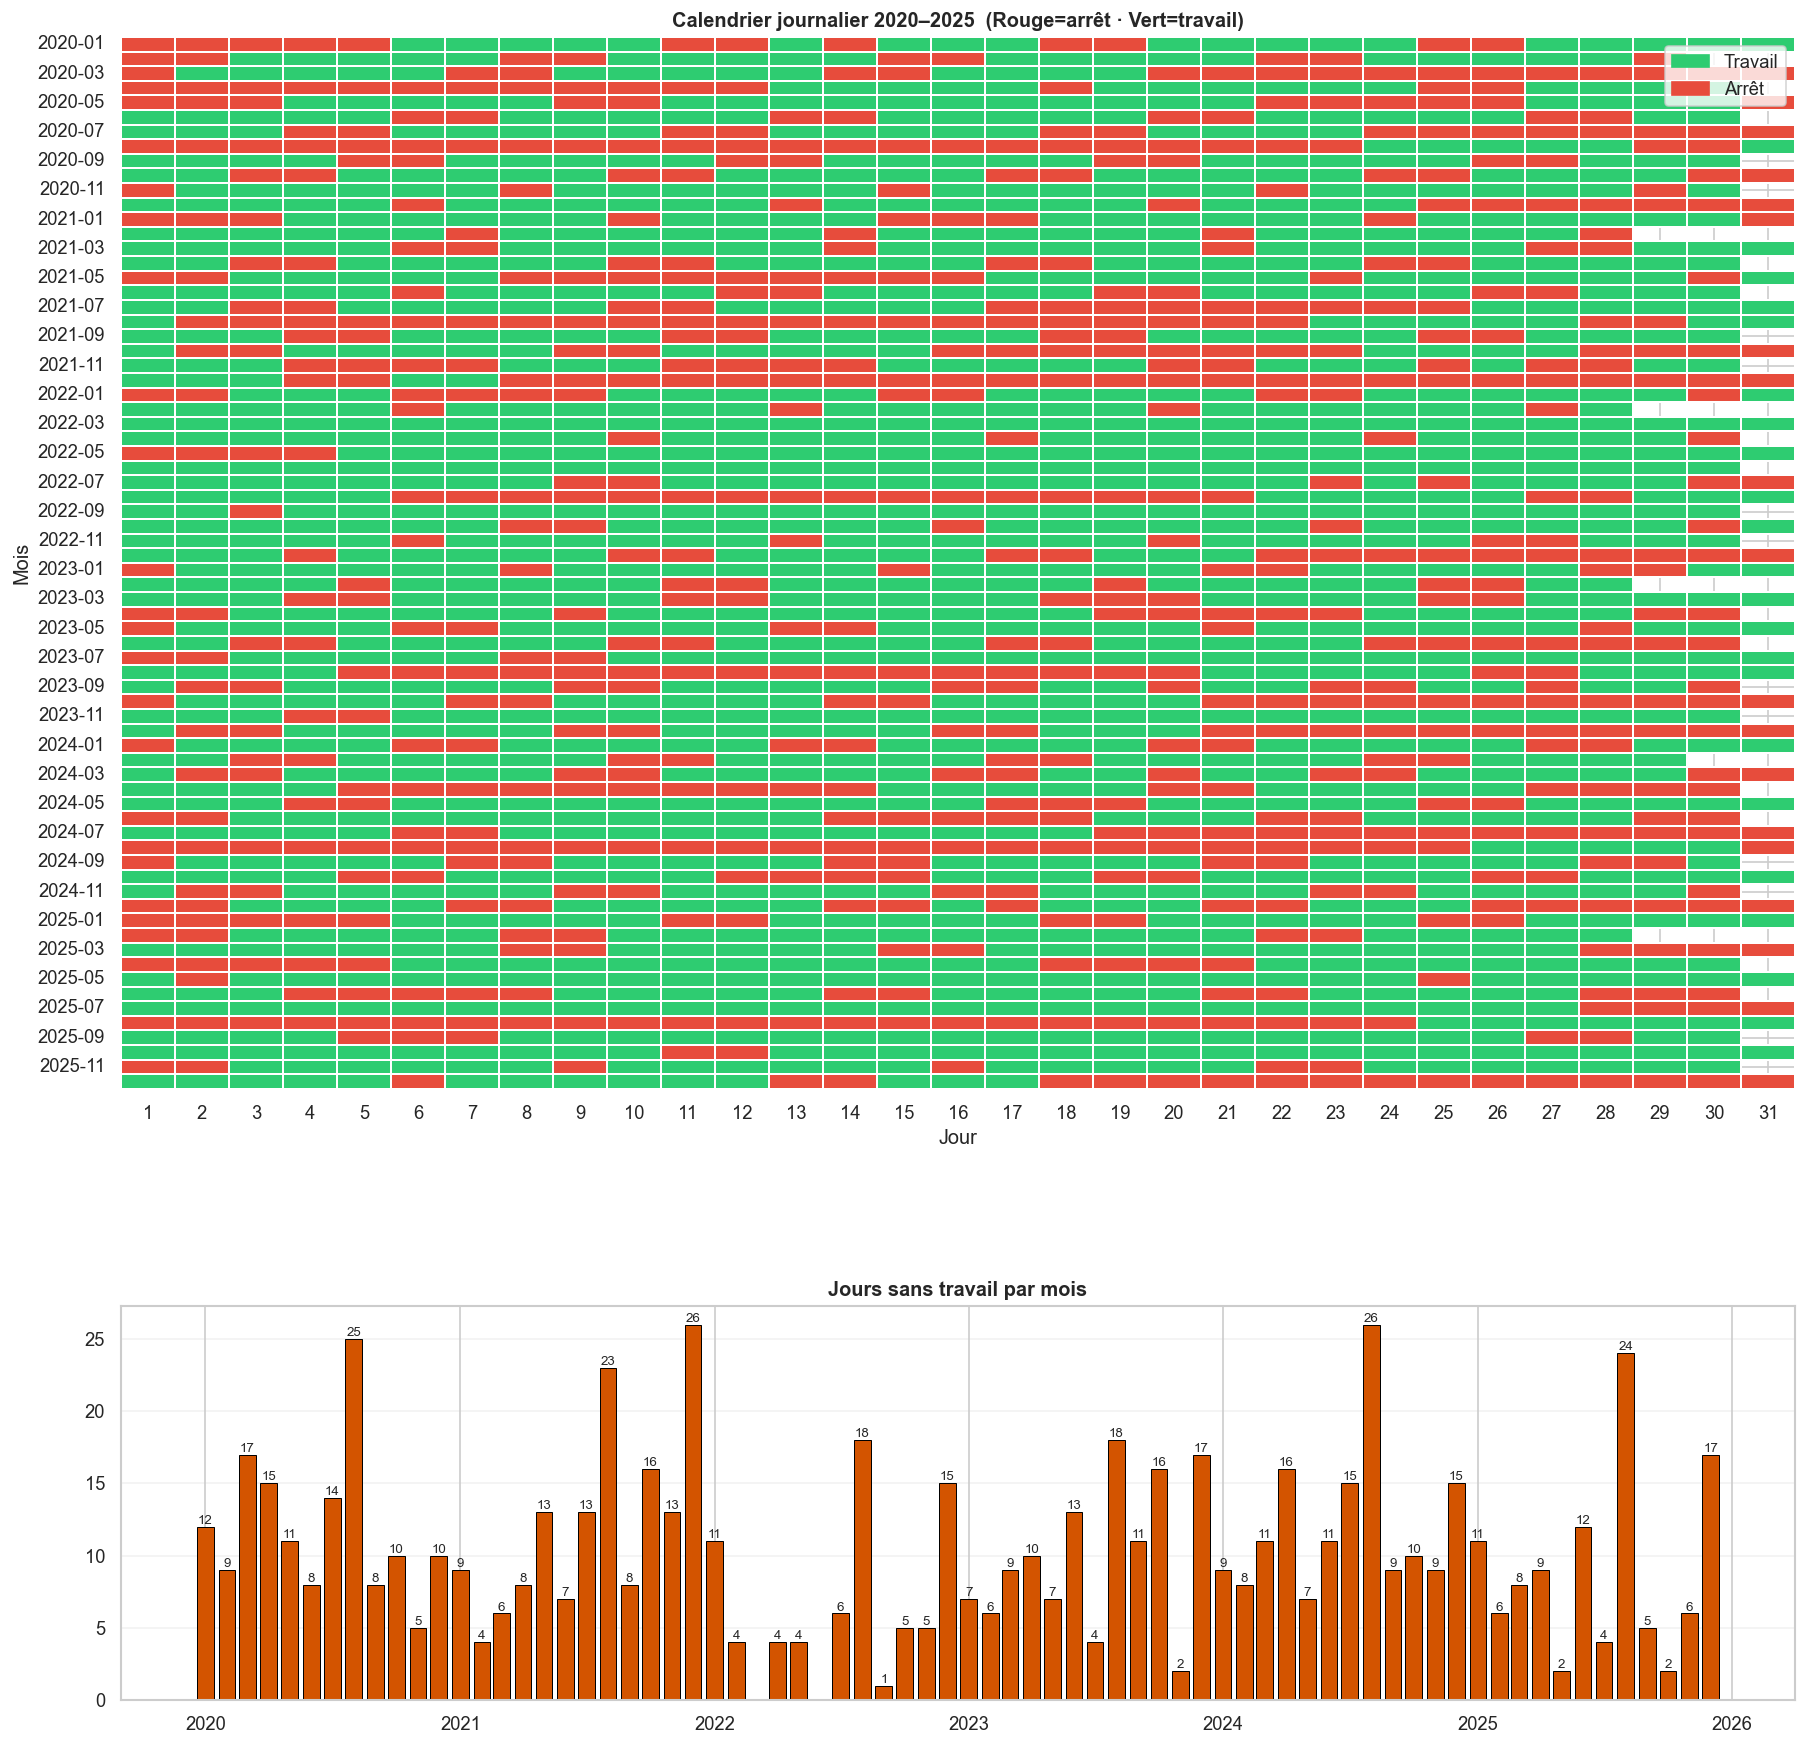


Jours sans travail répétés chaque année (2020–2025) : 0


,J/M,Années observées


In [14]:
start,end = pd.Timestamp("2020-01-01"), pd.Timestamp("2025-12-31")
dates_p = pd.to_datetime(df["Date de production"],errors="coerce")
dates_trav = pd.DatetimeIndex(
    dates_p[dates_p.between(start,end)].dropna().dt.normalize().unique()).sort_values()
cal = pd.date_range(start,end,freq="D")
statut = pd.Series(0,index=cal,dtype=int)
statut.loc[statut.index.isin(dates_trav)]=1
jsans = cal.difference(dates_trav)
jsans_m = pd.Series(1,index=jsans).resample("MS").sum().reindex(
    pd.date_range(start,end,freq="MS"),fill_value=0)

cdf = pd.DataFrame({"Date":statut.index,"S":statut.values})
cdf["Mois"]=cdf["Date"].dt.to_period("M").astype(str); cdf["Jour"]=cdf["Date"].dt.day
hmap = cdf.pivot(index="Mois",columns="Jour",values="S")

print(f"Jours calendrier : {len(cal)}  |  Travaillés : {statut.sum()}  |  Arrêts : {len(jsans)}")

fig=plt.figure(figsize=(18,18))
gs2=fig.add_gridspec(2,1,height_ratios=[4,1.5],hspace=0.3)
ax1=fig.add_subplot(gs2[0])
sns.heatmap(hmap,mask=hmap.isna(),cmap=ListedColormap(["#E74C3C","#2ECC71"]),
    cbar=False,linewidths=0.2,linecolor="white",ax=ax1)
ax1.set_title("Calendrier journalier 2020–2025  (Rouge=arrêt · Vert=travail)",fontweight="bold")
ax1.legend(handles=[mpatches.Patch(color="#2ECC71",label="Travail"),
    mpatches.Patch(color="#E74C3C",label="Arrêt")],loc="upper right")
ax2=fig.add_subplot(gs2[1])
bars=ax2.bar(jsans_m.index,jsans_m.values,width=24,color="#D35400",edgecolor="black",lw=0.6)
ax2.set_title("Jours sans travail par mois"); ax2.grid(axis="y",alpha=0.25)
for b,v in zip(bars,jsans_m.values):
    if v>0: ax2.text(b.get_x()+b.get_width()/2,v,f"{int(v)}",ha="center",va="bottom",fontsize=8)
plt.tight_layout(); plt.show()

# Jours fériés récurrents
nw=pd.DataFrame({"date":jsans})
nw["annee"]=nw["date"].dt.year; nw["mois"]=nw["date"].dt.month
nw["jour"]=nw["date"].dt.day;   nw["wd"]=nw["date"].dt.weekday
excl=((nw["mois"]==1)&(nw["jour"]<=3))|(nw["wd"]>=5)|(nw["mois"]==8)|((nw["mois"]==12)&(nw["jour"]>=22))
nwf=nw[~excl].copy()
nw2=nwf[nwf["annee"]==2020].sort_values("date").copy()
if not nw2.empty:
    nw2["g"]=(nw2["date"].diff().dt.days.ne(1)).cumsum()
    gs3=nw2.groupby("g").size()
    conf=set(nw2[nw2["g"].isin(gs3[gs3>3].index)]["date"])
    nwf=nwf[~nwf["date"].isin(conf)].copy()
repeat=nwf.groupby(["mois","jour"]).agg(nb=("annee","nunique"),ans=("annee",lambda s:",".join(map(str,sorted(s))))).reset_index()
tous=repeat[repeat["nb"]==6].sort_values(["mois","jour"]).copy()
tous["J/M"]=tous["jour"].astype(str).str.zfill(2)+"/"+tous["mois"].astype(str).str.zfill(2)
print(f"\nJours sans travail répétés chaque année (2020–2025) : {len(tous)}")
display(tous[["J/M","ans"]].rename(columns={"ans":"Années observées"}))

---
## 11. Inventaire des Codes Appareils & Gammes
**Objectif :** lister tous les codes distincts, les classer (actifs/anciens/peu fréquents) et établir la correspondance gamme→appareil(s).

In [15]:
# Appareils
app=df["Code appareil"].astype(str).str.strip(); app=app[~app.isin(["","nan","None"])]
print(f"CODES APPAREIL — {app.nunique()} distincts\n"+"-"*50)
for i,(c,n) in enumerate(app.value_counts().items(),1):
    print(f"  {i:3}. {c:15} ({n:>6,} occ.)")

# Gammes
gamme=df["Code gamme"].astype(str).str.strip(); gamme=gamme[~gamme.isin(["","nan","None"])]
print(f"\nCODES GAMME — {gamme.nunique()} distincts\n"+"-"*50)
for i,(c,n) in enumerate(gamme.value_counts().items(),1):
    print(f"  {i:3}. {c:15} ({n:>6,} occ.)")

# Tableau récapitulatif appareil×gamme
recap=df.groupby(["Code appareil","Code gamme"]).agg(
    {"Quantité produite":"sum","Heures travaillées":"sum"}).round(2)
recap.columns=["Quantité","Heures travaillées"]
recap["Productivité (u/h)"]=(recap["Quantité"]/recap["Heures travaillées"]).round(3)
print(f"\nCombinaisons (Appareil × Gamme) : {len(recap)}")
display(recap.sort_values("Quantité",ascending=False).head(20))

CODES APPAREIL — 86 distincts
--------------------------------------------------
    1. 79              ( 2,062 occ.)
    2. 44              ( 2,017 occ.)
    3. 71              ( 2,004 occ.)
    4. 95              ( 1,997 occ.)
    5. 100             ( 1,982 occ.)
    6. 98              ( 1,977 occ.)
    7. 49              ( 1,919 occ.)
    8. 132             ( 1,909 occ.)
    9. X28             ( 1,884 occ.)
   10. 77              ( 1,845 occ.)
   11. 97              ( 1,844 occ.)
   12. 58              ( 1,844 occ.)
   13. 76              ( 1,821 occ.)
   14. 81              ( 1,816 occ.)
   15. 110             ( 1,814 occ.)
   16. 107             ( 1,805 occ.)
   17. 43              ( 1,802 occ.)
   18. 75              ( 1,798 occ.)
   19. 120             ( 1,764 occ.)
   20. 82              ( 1,763 occ.)
   21. X49             ( 1,742 occ.)
   22. 69              ( 1,701 occ.)
   23. 51              ( 1,699 occ.)
   24. 54              ( 1,695 occ.)
   25. X50             ( 1,682 

,,Quantité,Heures travaillées,Productivité (u/h)
Code appareil,Code gamme,,,
X28,1653230AATN1,3091690,"5,256.750",588.137
X50,1172470AATN0,2809241,"4,490.490",625.598
X29,1653230AATN1,2775018,"5,568.500",498.342
X20,1510930AATN1,2738010,"5,960.750",459.340
X32,1950120AATN1,2516483,"4,080.240",616.749
40,1653240AATN0,2292099,"4,780.500",479.468
79,1172480AATN0,2084529,"4,248.360",490.667
ZP1,1950120AATN1,1787725,"3,220.000",555.194
X27,1010430AATN1,1779613,"3,316.500",536.594


In [16]:
# Classification des codes gamme
ANNEE_REF,SEUIL=2025,10
data_g=df[["Code gamme","Date de production"]].copy()
data_g["Code gamme"]=data_g["Code gamme"].astype(str).str.strip()
data_g=data_g[~data_g["Code gamme"].isin(["","nan","None"])]
data_g["Date de production"]=pd.to_datetime(data_g["Date de production"],errors="coerce")
data_g=data_g.dropna(subset=["Date de production"])
sg=data_g.groupby("Code gamme").agg(occ=("Code gamme","size"),
    first=("Date de production","min"),last=("Date de production","max")).reset_index()
sg["an_first"]=sg["first"].dt.year; sg["an_last"]=sg["last"].dt.year

anciens  = sg[sg["an_last"]<ANNEE_REF]["Code gamme"].tolist()
nouveaux = sg[(sg["an_first"]==ANNEE_REF)&(sg["an_last"]==ANNEE_REF)]["Code gamme"].tolist()
peu_freq = sg[(sg["occ"]<SEUIL)&(sg["an_last"]==ANNEE_REF)]["Code gamme"].tolist()
print(f"Anciens (inactifs en {ANNEE_REF})  : {len(anciens)}")
print(f"Nouveaux ({ANNEE_REF} seulement)   : {len(nouveaux)}")
print(f"Peu fréquents (actifs, occ<{SEUIL}): {len(peu_freq)}")
n=max(len(anciens),len(nouveaux),len(peu_freq))
display(pd.DataFrame({"Anciens":anciens+[""]*(n-len(anciens)),
    f"Nouveaux {ANNEE_REF}":nouveaux+[""]*(n-len(nouveaux)),
    "Peu fréquents actifs":peu_freq+[""]*(n-len(peu_freq))}))

# Correspondance gamme → appareils
temp=df[["Code gamme","Code appareil"]].copy().applymap(lambda x: str(x).strip())
temp=temp[(temp["Code gamme"]!="")&(temp["Code appareil"]!="")]
mapping=(temp.groupby("Code gamme")["Code appareil"]
    .apply(lambda s:", ".join(sorted(pd.unique(s),key=str.lower))).sort_index())
print(f"\nCorrespondance Code gamme → Appareil(s)\n"+"-"*60)
for g,a in mapping.items(): print(f"  {g:20}  {a}")

Anciens (inactifs en 2025)  : 197
Nouveaux (2025 seulement)   : 5
Peu fréquents (actifs, occ<10): 6


,Anciens,Nouveaux 2025,Peu fréquents actifs
0,1010430AATN1,1015930AATN0,1015930AATN0
1,1010440AATN1,1351730AATN2,1351730AATN2
2,1010520AATN0,1420830AATN0,1770330AATN0
3,1010530AATN0,1950330AATN0,1940330AATN1
4,1012370AATN1,1957070AATN0,1950330AATN0
...,...,...,...
192,2254140AATN1,,
193,2254150AATN0,,
194,2254160AATN0,,
195,2455040AATN0,,


AttributeError: 'DataFrame' object has no attribute 'applymap'

---
## 12. KPI Annuels — Efficacité, TRS & Productivité
**Objectif :** calculer et visualiser les indicateurs clés de performance par année.

In [ ]:
# ── Efficacité (HP/HT) ───────────────────────────────────────────────────────
kpi_a=df.dropna(subset=["Année"]).groupby("Année",as_index=False)[
    ["Heures produites","Heures travaillées","Quantité produite"]].sum().sort_values("Année")
kpi_a["Efficacité (%)"]      =(kpi_a["Heures produites"]/kpi_a["Heures travaillées"]*100).round(2)
kpi_a["Prod brute (u/HT)"]   =(kpi_a["Quantité produite"]/kpi_a["Heures travaillées"]).round(3)
kpi_a["Prod effective (u/HP)"]=(kpi_a["Quantité produite"]/kpi_a["Heures produites"]).round(3)

# ── TRS (Disponibilité × Performance × Qualité) ──────────────────────────────
DISPO,QUAL=100.0,85.0
kpi_a["Performance (%)"]  =(kpi_a["Heures produites"]/kpi_a["Heures travaillées"]*100).round(2)
kpi_a["Disponibilité (%)"]=DISPO; kpi_a["Qualité (%)"]=QUAL
kpi_a["TRS (%)"]          =(kpi_a["Disponibilité (%)"]/100*kpi_a["Performance (%)"]/100*kpi_a["Qualité (%)"]/100*100).round(2)

print("KPI ANNUELS COMPLETS :")
display(kpi_a[["Année","Heures travaillées","Heures produites","Quantité produite",
               "Efficacité (%)","TRS (%)","Prod brute (u/HT)","Prod effective (u/HP)"]])

# Visualisation
fig,axes=plt.subplots(2,2,figsize=(16,10))
fig.suptitle("KPI Annuels — Bontaz Tunisie",fontsize=14,fontweight="bold")

for ax,col,color,title in [
    (axes[0,0],"Quantité produite","#2E86AB","Production annuelle (unités)"),
    (axes[0,1],"Efficacité (%)","#4C72B0","Taux d'Efficacité HP/HT (%)"),
    (axes[1,0],"TRS (%)","#2A9D8F","TRS annuel (%)"),
    (axes[1,1],"Prod effective (u/HP)","#E76F51","Productivité effective (u/HP)")]:
    sns.barplot(data=kpi_a,x="Année",y=col,color=color,ax=ax)
    ax.set_title(title); ax.set_xlabel("Année"); ax.grid(axis="y",ls="--",alpha=0.35)
    for i,row in kpi_a.reset_index(drop=True).iterrows():
        v=row[col]
        if pd.notna(v): ax.text(i,v,f"{v:.2f}" if isinstance(v,float) else f"{v:,.0f}",
            ha="center",va="bottom",fontsize=9,fontweight="bold")

plt.tight_layout(); plt.show()

---
## 13. Analyse de Pareto 80/20
**Objectif :** identifier les combinaisons (appareil, gamme) qui représentent 80 % de la production totale.

In [ ]:
# Top 5 gammes
top5_g=df.groupby("Code gamme")["Quantité produite"].sum().nlargest(5).reset_index()
tot=df["Quantité produite"].sum()
top5_g["% total"]=(top5_g["Quantité produite"]/tot*100).round(2)
print("TOP 5 GAMMES :"); display(top5_g)

# Top 20 combinaisons Appareil × Gamme
top20=recap.sort_values("Quantité",ascending=False).head(20).copy()
top20["Combi"]=top20.index.map(lambda x: f"{x[0]} / {x[1]}")
fig,axes=plt.subplots(1,2,figsize=(18,7))
fig.suptitle("Pareto 80/20 — Production par Combinaison Appareil/Gamme",fontweight="bold",fontsize=13)

ax=axes[0]
sns.barplot(data=top20,x="Quantité",y="Combi",hue="Combi",palette="viridis",dodge=False,legend=False,ax=ax)
ax.set_title("Top 20 combinaisons Appareil/Gamme"); ax.set_xlabel("Quantité produite")
for container in ax.containers: ax.bar_label(container,fmt="{:,.0f}",padding=5,fontsize=8)
ax.grid(axis="x",ls="--",alpha=0.5)

# Diagramme cumulé
ax=axes[1]
pareto=recap["Quantité"].sort_values(ascending=False).reset_index()
pareto["Combi"]=pareto.apply(lambda r: f"{r['Code appareil']} / {r['Code gamme']}",axis=1)
pareto["%"]=pareto["Quantité"]/pareto["Quantité"].sum()*100
pareto["%c"]=pareto["%"].cumsum()
idx80=pareto[pareto["%c"]>=80].index.min(); nb80=int(idx80+1)
p80=pareto.iloc[:nb80].copy(); p80["Rang"]=range(1,nb80+1)
print(f"\nCombinations pour 80% de la production : {nb80}/{len(pareto)} ({nb80/len(pareto)*100:.1f}%)")

ax.bar(p80["Rang"],p80["Quantité"],color="#4C72B0",alpha=0.85)
ax2t=ax.twinx()
ax2t.plot(p80["Rang"],p80["%c"],color="crimson",lw=2,marker="o",ms=3)
ax2t.axhline(80,color="green",ls="--",lw=1.5,label="Seuil 80%")
ax2t.axvline(nb80,color="orange",ls="--",lw=1.5)
ax2t.set_ylabel("% cumulé"); ax2t.set_ylim(0,100); ax2t.legend(loc="lower right")
ax.set_xlabel("Rang (1=plus produit)"); ax.set_ylabel("Quantité"); ax.set_title("Diagramme de Pareto cumulé")
ax.grid(axis="y",alpha=0.3)

plt.tight_layout(); plt.show()

---
## 14. Analyse des Arrêts & Pertes
**Objectif :** quantifier les heures perdues (HT−HP) par appareil, identifier les 3 machines les plus impactées et les décomposer par gamme et par année.

In [ ]:
pertes=df.groupby("Code appareil",as_index=False).agg(
    HT=("Heures travaillées","sum"),HP=("Heures produites","sum"))
pertes["Heures_Perte"]=(pertes["HT"]-pertes["HP"]).clip(lower=0)
pertes["Taux_Perte_%"]=np.where(pertes["HT"]>0,pertes["Heures_Perte"]/pertes["HT"]*100,np.nan).round(2)
pertes=pertes[~pertes["Code appareil"].isin(["","nan","None"])].sort_values("Heures_Perte",ascending=False).reset_index(drop=True)

tot_ht=pertes["HT"].sum(); tot_hp=pertes["HP"].sum(); tot_p=pertes["Heures_Perte"].sum()
print(f"BILAN PERTES GLOBAL : {tot_p:,.1f} h perdues ({tot_p/tot_ht*100:.2f}% du temps travaillé)")
display(pertes.head(10))

# Visualisation
fig,axes=plt.subplots(1,2,figsize=(18,6))
fig.suptitle("Analyse des Arrêts/Pertes par Appareil",fontweight="bold",fontsize=13)
top15=pertes.head(15).sort_values("Heures_Perte")
colors_p=["#C0392B" if t>20 else "#E67E22" if t>10 else "#F1C40F" for t in top15["Taux_Perte_%"]]
axes[0].barh(top15["Code appareil"],top15["Heures_Perte"],color=colors_p)
axes[0].set_title("Top 15 — Heures de perte"); axes[0].set_xlabel("Heures perdues")
for container in axes[0].containers: axes[0].bar_label(container,fmt="%.1f",padding=4,fontsize=9)
axes[0].grid(axis="x",ls="--",alpha=0.4)

top15b=pertes.head(15).sort_values("Taux_Perte_%")
axes[1].barh(top15b["Code appareil"],top15b["Taux_Perte_%"],color="#9B59B6",alpha=0.8)
axes[1].set_title("Top 15 — Taux de perte (%)"); axes[1].set_xlabel("%")
for container in axes[1].containers: axes[1].bar_label(container,fmt="%.1f%",padding=4,fontsize=9)
axes[1].grid(axis="x",ls="--",alpha=0.4)

plt.tight_layout(); plt.show()

In [ ]:
# Analyse détaillée TOP 3
top3=pertes.head(3).copy(); t3c=top3["Code appareil"].tolist()
df_c=df[~df["Code appareil"].isin(["","nan","None"])].copy()
df_c[["Heures travaillées","Heures produites"]]=df_c[["Heures travaillées","Heures produites"]].apply(pd.to_numeric,errors="coerce")

fig,axes=plt.subplots(2,2,figsize=(16,12))
fig.suptitle("Analyse Détaillée — TOP 3 Appareils avec le plus de Pertes",fontsize=14,fontweight="bold")

for _,row in top3.iterrows():
    app=row["Code appareil"]
    print(f"\n{'='*70}\nAPPAREIL : {app}  |  Perte={row['Heures_Perte']:.1f}h  |  Taux={row['Taux_Perte_%']:.2f}%")
    da=df_c[df_c["Code appareil"]==app].copy()
    # Par gamme
    gp=da.groupby("Code gamme").agg({"Heures travaillées":"sum","Heures produites":"sum"})
    gp["Perte"]=(gp["Heures travaillées"]-gp["Heures produites"]).clip(0)
    gp["Taux%"]=(gp["Perte"]/gp["Heures travaillées"]*100).round(2)
    print("  Top 5 gammes :")
    for g,r2 in gp.sort_values("Perte",ascending=False).head(5).iterrows():
        print(f"    {g:18}: {r2['Perte']:>7.1f}h ({r2['Taux%']:.1f}%)")
    # Par année
    da["Année_l"]=da["Date de production"].dt.year
    ya=da.groupby("Année_l").agg({"Heures travaillées":"sum","Heures produites":"sum"})
    ya["Perte"]=(ya["Heures travaillées"]-ya["Heures produites"]).clip(0)
    ya["Taux%"]=(ya["Perte"]/ya["Heures travaillées"]*100).round(2)
    print("  Évolution par année :")
    for yr,r2 in ya.iterrows(): print(f"    {yr}: {r2['Perte']:>7.1f}h ({r2['Taux%']:.1f}%)")

ax1=axes[0,0]; b=ax1.bar(range(3),top3["Heures_Perte"],color=["#ff9999","#66b3ff","#99ff99"])
ax1.set_title("Heures de perte"); ax1.set_xticks(range(3)); ax1.set_xticklabels(t3c,rotation=30)
for b2 in b: ax1.text(b2.get_x()+b2.get_width()/2,b2.get_height(),f"{b2.get_height():.0f}h",ha="center",va="bottom",fontsize=9)

ax2=axes[0,1]; b=ax2.bar(range(3),top3["Taux_Perte_%"],color=["#ff9999","#66b3ff","#99ff99"])
ax2.set_title("Taux de perte (%)"); ax2.set_xticks(range(3)); ax2.set_xticklabels(t3c,rotation=30)
for b2 in b: ax2.text(b2.get_x()+b2.get_width()/2,b2.get_height(),f"{b2.get_height():.1f}%",ha="center",va="bottom",fontsize=9)

ax3=axes[1,0]; w=0.35; x=range(3)
ax3.bar([i-w/2 for i in x],top3["HT"],w,label="HT",color="skyblue")
ax3.bar([i+w/2 for i in x],top3["HP"],w,label="HP",color="lightcoral")
ax3.set_title("HT vs HP"); ax3.set_xticks(x); ax3.set_xticklabels(t3c,rotation=30); ax3.legend()

ax4=axes[1,1]
ax4.pie(top3["Heures_Perte"],labels=t3c,autopct="%1.1f%%",
    colors=["#ff9999","#66b3ff","#99ff99"],startangle=90)
ax4.set_title("Répartition pertes TOP 3")

plt.tight_layout(); plt.show()
pct3=top3["Heures_Perte"].sum()/tot_p*100
print(f"\nLes TOP 3 représentent {pct3:.1f}% des pertes totales.")

---
## 15. Dashboard Exécutif Final
**Objectif :** tableau de bord synthétique avec KPI cards colorées, évolution mensuelle, taux de perte trimestriel, top appareils et répartition par équipe.

In [ ]:
ht_d=df["Heures travaillées"].sum(); hp_d=df["Heures produites"].sum()
q_d=df["Quantité produite"].sum(); p_d=(ht_d-hp_d)
tp=p_d/ht_d*100; pv=hp_d/ht_d*100

monthly_db=df.groupby("Année_Mois").agg(
    Quantité=("Quantité produite","sum"),
    HT=("Heures travaillées","sum"),HP=("Heures produites","sum")).reset_index()
monthly_db["Date"]=pd.to_datetime(monthly_db["Année_Mois"])
monthly_db["Taux_Perte"]=(monthly_db["HT"]-monthly_db["HP"])/monthly_db["HT"]*100
monthly_db=monthly_db.sort_values("Date")

qtr_db=df.copy()
qtr_db["Q_label"]=qtr_db["Date de production"].dt.to_period("Q").astype(str)
qtr_db=qtr_db.groupby("Q_label").agg(HT=("Heures travaillées","sum"),HP=("Heures produites","sum")).reset_index()
qtr_db["Taux_Perte"]=(qtr_db["HT"]-qtr_db["HP"])/qtr_db["HT"]*100

tapp=df.groupby("Code appareil")["Heures_Perte"].sum().nlargest(8).reset_index()
teq =df.groupby("Equipe")["Quantité produite"].sum()

fig=plt.figure(figsize=(20,13),facecolor="#F8F9FA")
gs3=gridspec.GridSpec(3,3,hspace=0.45,wspace=0.3,height_ratios=[0.9,2.2,2.2])
fig.suptitle("DASHBOARD PRODUCTION — BONTAZ TUNISIE (2020–2025)",
    fontsize=17,fontweight="bold",color="#2C3E50",y=0.98)

# KPI cards
for col,(val,lab,color) in enumerate([
    (f"{q_d:,.0f}","Unités produites","#27AE60"),
    (f"{pv:.1f}%","Efficacité HP/HT","#2980B9"),
    (f"{tp:.1f}%","Taux de perte","#E74C3C")]):
    ax=fig.add_subplot(gs3[0,col]); ax.set_facecolor(color)
    ax.text(0.5,0.62,val,ha="center",va="center",fontsize=22,fontweight="bold",color="white",transform=ax.transAxes)
    ax.text(0.5,0.25,lab,ha="center",va="center",fontsize=11,color="white",transform=ax.transAxes)
    ax.axis("off")

# Évolution mensuelle
ax1=fig.add_subplot(gs3[1,:2])
ax1.fill_between(monthly_db["Date"],monthly_db["Quantité"],alpha=0.2,color="#2E86AB")
ax1.plot(monthly_db["Date"],monthly_db["Quantité"],"-o",lw=2,ms=3,color="#2E86AB",label="Quantité")
ax1b=ax1.twinx()
ax1b.plot(monthly_db["Date"],monthly_db["Taux_Perte"],"-s",lw=1.5,ms=3,color="#E74C3C",alpha=0.7,label="Taux perte %")
ax1b.set_ylabel("Taux perte (%)"); ax1.set_ylabel("Quantité"); ax1.set_title("Évolution mensuelle")
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax1.get_xticklabels(),rotation=45)
lines1,labs1=ax1.get_legend_handles_labels(); lines2,labs2=ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2,labs1+labs2,loc="upper left",fontsize=8)

# Taux perte trimestriel
ax2=fig.add_subplot(gs3[1,2])
sns.barplot(data=qtr_db,x="Q_label",y="Taux_Perte",color="#E07A5F",ax=ax2)
ax2.set_title("Taux de perte trimestriel (%)"); ax2.tick_params(axis="x",rotation=45)

# Top 8 appareils
ax3=fig.add_subplot(gs3[2,:2])
sns.barplot(data=tapp,x="Code appareil",y="Heures_Perte",color="#3D5A80",ax=ax3)
ax3.set_title("Top 8 appareils — Heures de perte"); ax3.tick_params(axis="x",rotation=45)

# Répartition par équipe
ax4=fig.add_subplot(gs3[2,2])
if len(teq):
    ax4.pie(teq.values,labels=teq.index,autopct="%1.1f%%",startangle=90)
    ax4.set_title("Production par équipe")

plt.savefig("dashboard_bontaz.png",dpi=120,bbox_inches="tight")
plt.show()
print("Dashboard enregistré : dashboard_bontaz.png")

---
## 16. Préparation des Données pour la Prédiction
**Objectif :** construire la série mensuelle des quantités produites et créer les features temporels (lags, moyennes mobiles, encodage cyclique, trend) pour les modèles de ML.

In [ ]:
def build_monthly_ts(dataframe, cutoff="2026-01-01"):
    """Agrège les données en série mensuelle et génère les features."""
    d = dataframe[dataframe["Date de production"] < pd.Timestamp(cutoff)].copy()
    d["Mois_period"] = d["Date de production"].dt.to_period("M").dt.to_timestamp()
    monthly = d.groupby("Mois_period")["Quantité produite"].sum().sort_index()
    monthly = monthly.reindex(
        pd.date_range(monthly.index.min(), monthly.index.max(), freq="MS"),
        fill_value=0.0)
    monthly.index.name = "Date"
    df_m = monthly.reset_index(); df_m.columns = ["Date","Quantité"]
    df_m["Année"]     = df_m["Date"].dt.year
    df_m["Mois"]      = df_m["Date"].dt.month
    df_m["Trimestre"] = df_m["Date"].dt.quarter
    df_m["Trend"]     = np.arange(len(df_m))
    df_m["Sin_12"]    = np.sin(2*np.pi*df_m["Mois"]/12)
    df_m["Cos_12"]    = np.cos(2*np.pi*df_m["Mois"]/12)
    df_m["Sin_6"]     = np.sin(2*np.pi*df_m["Mois"]/6)
    df_m["Cos_6"]     = np.cos(2*np.pi*df_m["Mois"]/6)
    for lag in [1,2,3,6,12]:
        df_m[f"Lag_{lag}"] = df_m["Quantité"].shift(lag)
    for win in [3,6,12]:
        df_m[f"MA_{win}"]  = df_m["Quantité"].rolling(win).mean()
        df_m[f"Std_{win}"] = df_m["Quantité"].rolling(win).std()
    df_m["Growth_MoM"] = df_m["Quantité"].pct_change(1)
    df_m["Growth_YoY"] = df_m["Quantité"].pct_change(12)
    return df_m.dropna().reset_index(drop=True)

FEATURE_COLS = [
    "Mois","Année","Trimestre","Trend",
    "Sin_12","Cos_12","Sin_6","Cos_6",
    "Lag_1","Lag_2","Lag_3","Lag_6","Lag_12",
    "MA_3","MA_6","MA_12","Std_3","Std_6",
    "Growth_MoM","Growth_YoY"
]

df_monthly = build_monthly_ts(df)
print(f"Série mensuelle : {len(df_monthly)} mois")
print(f"Période : {df_monthly['Date'].min().date()} → {df_monthly['Date'].max().date()}")
print(df_monthly[["Date","Quantité"]].to_string(index=False))

# Split chronologique train/test (80/20)
split = int(len(df_monthly)*0.8)
X = df_monthly[FEATURE_COLS].values
y = df_monthly["Quantité"].values
X_train,X_test = X[:split],X[split:]
y_train,y_test = y[:split],y[split:]
dates_test = df_monthly["Date"].iloc[split:].values
print(f"\nTrain : {split} mois  |  Test : {len(df_monthly)-split} mois")

# Visualisation série mensuelle
plt.figure(figsize=(13,4))
plt.plot(df_monthly["Date"],df_monthly["Quantité"],"-o",lw=2,ms=4,color="#2E86AB")
plt.fill_between(df_monthly["Date"],df_monthly["Quantité"],alpha=0.15,color="#2E86AB")
plt.title("Série mensuelle de production — 2020–2025",fontweight="bold")
plt.xlabel("Mois"); plt.ylabel("Quantité produite"); plt.grid(alpha=0.25)
plt.tight_layout(); plt.show()

---
## 17. Comparaison de Modèles de Prédiction
**Objectif :** évaluer et comparer plusieurs modèles — XGBoost, Random Forest, Gradient Boosting, Ridge — sur le jeu de test chronologique.

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

def compute_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true-y_pred)/(y_true+1e-8)))*100
    return {"Modèle":name,"MAE":round(mae,1),"RMSE":round(rmse,1),"R²":round(r2,4),"MAPE (%)":round(mape,2)}

MODELS={}; results=[]

# Ridge
sc=StandardScaler()
Xtr_sc=sc.fit_transform(X_train); Xte_sc=sc.transform(X_test)
ridge=Ridge(alpha=1.0); ridge.fit(Xtr_sc,y_train)
p_ridge=ridge.predict(Xte_sc).clip(0)
MODELS["Ridge"]=(ridge,sc,"scaled"); results.append(compute_metrics(y_test,p_ridge,"Ridge"))
print("Ridge entraîné")

# Random Forest
rf=RandomForestRegressor(n_estimators=300,max_depth=8,min_samples_leaf=2,random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
p_rf=rf.predict(X_test).clip(0)
MODELS["Random Forest"]=(rf,None,"raw"); results.append(compute_metrics(y_test,p_rf,"Random Forest"))
print("Random Forest entraîné")

# Gradient Boosting
gb=GradientBoostingRegressor(n_estimators=200,max_depth=5,learning_rate=0.1,subsample=0.8,random_state=42)
gb.fit(X_train,y_train)
p_gb=gb.predict(X_test).clip(0)
MODELS["Gradient Boosting"]=(gb,None,"raw"); results.append(compute_metrics(y_test,p_gb,"Gradient Boosting"))
print("Gradient Boosting entraîné")

# XGBoost
try:
    from xgboost import XGBRegressor
    xgb=XGBRegressor(n_estimators=300,max_depth=6,learning_rate=0.08,
        subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=1.0,
        random_state=42,verbosity=0,n_jobs=-1)
    xgb.fit(X_train,y_train)
    p_xgb=xgb.predict(X_test).clip(0)
    MODELS["XGBoost"]=(xgb,None,"raw"); results.append(compute_metrics(y_test,p_xgb,"XGBoost"))
    print("XGBoost entraîné")
except ImportError:
    print("XGBoost non disponible — ignoré")

# Résultats
results_df=pd.DataFrame(results).sort_values("RMSE")
print("\n"+"="*70)
print("COMPARAISON DES MODÈLES — TEST SET")
print("="*70)
display(results_df)

# Visualisation prédictions
fig,axes=plt.subplots(len(results_df),1,figsize=(14,4*len(results_df)))
if len(results_df)==1: axes=[axes]
preds_all={"Ridge":p_ridge,"Random Forest":p_rf,"Gradient Boosting":p_gb}
try: preds_all["XGBoost"]=p_xgb
except: pass
colors_m={"Ridge":"#9B59B6","Random Forest":"#27AE60","Gradient Boosting":"#E67E22","XGBoost":"#2E86AB"}
for ax,(_,row) in zip(axes,results_df.iterrows()):
    nom=row["Modèle"]
    if nom not in preds_all: continue
    ax.plot(dates_test,y_test,"-o",lw=2,ms=5,color="black",label="Réel")
    ax.plot(dates_test,preds_all[nom],"-s",lw=2,ms=5,color=colors_m.get(nom,"#E74C3C"),label=f"Prédit ({nom})")
    ax.fill_between(dates_test,y_test,preds_all[nom],alpha=0.15,color=colors_m.get(nom,"#E74C3C"))
    ax.set_title(f"{nom}  |  MAE={row['MAE']:,.1f}  RMSE={row['RMSE']:,.1f}  R²={row['R²']:.4f}  MAPE={row['MAPE (%)']:.2f}%")
    ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

BEST_MODEL_NAME=results_df.iloc[0]["Modèle"]
print(f"\nMeilleur modèle : {BEST_MODEL_NAME}")

---
## 18. Modèle Final — Validation Croisée & Prévision 2026
**Objectif :** ré-entraîner le meilleur modèle avec validation croisée temporelle (TimeSeriesSplit), produire les prévisions mensuelles 2026 avec intervalles de confiance (bootstrap).

In [ ]:
# Sélectionner le meilleur modèle
best_obj, best_sc, best_type = MODELS[BEST_MODEL_NAME]

# ── Validation croisée TimeSeriesSplit ────────────────────────────────────────
print("="*70)
print(f"VALIDATION CROISÉE TEMPORELLE — {BEST_MODEL_NAME}")
print("="*70)

tscv=TimeSeriesSplit(n_splits=5)
cv_maes,cv_mapes,cv_r2s=[],[],[]

fig_cv,axes_cv=plt.subplots(2,3,figsize=(18,9))
fig_cv.suptitle(f"Validation Croisée — {BEST_MODEL_NAME}",fontsize=14,fontweight="bold")

for fold,(tr_idx,val_idx) in enumerate(tscv.split(X)):
    Xf_tr,Xf_val=X[tr_idx],X[val_idx]
    yf_tr,yf_val=y[tr_idx],y[val_idx]
    if best_type=="scaled":
        sc2=StandardScaler(); Xf_tr_s=sc2.fit_transform(Xf_tr); Xf_val_s=sc2.transform(Xf_val)
    else:
        Xf_tr_s,Xf_val_s=Xf_tr,Xf_val
    m_fold=type(best_obj)(**({k:v for k,v in best_obj.get_params().items() if k!="verbose"} if hasattr(best_obj,"get_params") else {}))
    m_fold.fit(Xf_tr_s,yf_tr)
    pred_fold=m_fold.predict(Xf_val_s).clip(0)
    mae_f=mean_absolute_error(yf_val,pred_fold)
    mape_f=np.mean(np.abs((yf_val-pred_fold)/(yf_val+1e-8)))*100
    r2_f=r2_score(yf_val,pred_fold)
    cv_maes.append(mae_f); cv_mapes.append(mape_f); cv_r2s.append(r2_f)
    ax=axes_cv.flatten()[fold]
    ax.plot(yf_val,"-o",lw=2,ms=4,label="Réel",color="black")
    ax.plot(pred_fold,"-s",lw=2,ms=4,label="Prédit",color="#E74C3C")
    ax.set_title(f"Fold {fold+1} — MAE={mae_f:,.1f}  MAPE={mape_f:.1f}%  R²={r2_f:.3f}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes_cv.flatten()[-1].axis("off")
plt.tight_layout(); plt.show()

print(f"\nCV (5 folds) — MAPE moy : {np.mean(cv_mapes):.2f}%  |  MAE moy : {np.mean(cv_maes):,.1f}  |  R² moy : {np.mean(cv_r2s):.4f}")

# ── Réentraînement complet ────────────────────────────────────────────────────
if best_type=="scaled":
    scf=StandardScaler(); X_f=scf.fit_transform(X)
else:
    scf=None; X_f=X
final_model=type(best_obj)(**({k:v for k,v in best_obj.get_params().items() if k!="verbose"} if hasattr(best_obj,"get_params") else {}))
final_model.fit(X_f,y)
print(f"\nModèle final entraîné sur {len(X)} mois.")

In [ ]:
# ── Prévision récursive 2026 avec intervalles de confiance (bootstrap) ────────
ms_s = df_monthly.set_index("Date")["Quantité"].copy()

def build_row(series, m):
    def lag(n): return series.get(m-pd.DateOffset(months=n),np.nan)
    arr=np.array([lag(1),lag(2),lag(3),lag(6),lag(12),
        np.nanmean([lag(i) for i in[1,2,3]]),np.nanmean([lag(i) for i in[1,2,3,4,5,6]]),
        np.nanmean([lag(i) for i in range(1,13)]),
        np.nanstd([lag(i) for i in[1,2,3]]),np.nanstd([lag(i) for i in[1,2,3,4,5,6]]),
        np.nan,np.nan,  # Growth_MoM, Growth_YoY — non utilisés en inférence récursive
        m.month,df_monthly["Année"].max(),m.quarter,len(ms_s),  # Trend approx
        np.sin(2*np.pi*m.month/12),np.cos(2*np.pi*m.month/12),
        np.sin(2*np.pi*m.month/6), np.cos(2*np.pi*m.month/6)])
    return arr

# Prévision déterministe
series_ext=ms_s.copy()
preds_2026,months_2026=[],[]
for m in pd.date_range("2026-01-01","2026-12-01",freq="MS"):
    row=pd.DataFrame([[m.month,m.year,m.quarter,len(series_ext),
        np.sin(2*np.pi*m.month/12),np.cos(2*np.pi*m.month/12),
        np.sin(2*np.pi*m.month/6),np.cos(2*np.pi*m.month/6)]
        +[series_ext.get(m-pd.DateOffset(months=n),np.nan) for n in[1,2,3,6,12]]
        +[series_ext.iloc[-min(w,len(series_ext)):].mean() for w in[3,6,12]]
        +[series_ext.iloc[-min(w,len(series_ext)):].std() for w in[3,6]]
        +[series_ext.pct_change(1).iloc[-1] if len(series_ext)>1 else np.nan,
           series_ext.pct_change(12).iloc[-1] if len(series_ext)>12 else np.nan]
        ],columns=FEATURE_COLS)
    Xr=scf.transform(row.values) if best_type=="scaled" else row.values
    p=max(0.0,float(final_model.predict(Xr)[0]))
    preds_2026.append(p); months_2026.append(m); series_ext.loc[m]=p

pred_2026=np.array(preds_2026)

# Bootstrap CI
N_BOOT=200
boot_preds=np.zeros((N_BOOT,12))
for b in range(N_BOOT):
    sext_b=ms_s.copy(); boot_p=[]
    for i,m in enumerate(months_2026):
        row=pd.DataFrame([[m.month,m.year,m.quarter,len(sext_b),
            np.sin(2*np.pi*m.month/12),np.cos(2*np.pi*m.month/12),
            np.sin(2*np.pi*m.month/6),np.cos(2*np.pi*m.month/6)]
            +[sext_b.get(m-pd.DateOffset(months=n),np.nan) for n in[1,2,3,6,12]]
            +[sext_b.iloc[-min(w,len(sext_b)):].mean() for w in[3,6,12]]
            +[sext_b.iloc[-min(w,len(sext_b)):].std() for w in[3,6]]
            +[sext_b.pct_change(1).iloc[-1] if len(sext_b)>1 else np.nan,
               sext_b.pct_change(12).iloc[-1] if len(sext_b)>12 else np.nan]
            ],columns=FEATURE_COLS)
        noise=np.random.normal(0,np.mean(cv_maes)*0.3,row.shape)
        Xr=(scf.transform(row.values)+noise) if best_type=="scaled" else (row.values+noise)
        p=max(0.0,float(final_model.predict(Xr)[0]))
        boot_p.append(p); sext_b.loc[m]=p
    boot_preds[b]=boot_p

lower_2026=np.percentile(boot_preds,5,axis=0)
upper_2026=np.percentile(boot_preds,95,axis=0)

forecast_df=pd.DataFrame({
    "Mois":months_2026,
    "Quantité prédite":pred_2026.round(0).astype(int),
    "IC90 Bas":lower_2026.round(0).astype(int),
    "IC90 Haut":upper_2026.round(0).astype(int)
})

print(f"PRÉVISIONS 2026 — {BEST_MODEL_NAME}")
print(forecast_df.to_string(index=False))
print(f"\nTotal prédit 2026 : {pred_2026.sum():,.0f}")
print(f"IC90 Bas : {lower_2026.sum():,.0f}  |  IC90 Haut : {upper_2026.sum():,.0f}")

In [ ]:
# Graphes prévision
fig,axes=plt.subplots(2,1,figsize=(14,10))
fig.suptitle(f"Prévision 2026 — {BEST_MODEL_NAME}  |  MAPE CV : {np.mean(cv_mapes):.2f}%",
    fontsize=14,fontweight="bold")

# Mensuel (24 derniers mois + 2026)
ax=axes[0]
hp_plot=ms_s[ms_s.index>=ms_s.index.max()-pd.DateOffset(months=23)]
ax.plot(hp_plot.index,hp_plot.values,"-o",lw=2,ms=5,color="black",label="Historique")
ax.plot(months_2026,pred_2026,"-o",lw=2,ms=5,color="#E74C3C",label=f"Prévision 2026 ({BEST_MODEL_NAME})")
ax.fill_between(months_2026,lower_2026,upper_2026,alpha=0.2,color="#E74C3C",label="IC 90%")
ax.set_title("Prévision mensuelle 2026 avec intervalle de confiance 90%")
ax.set_ylabel("Quantité produite"); ax.legend(); ax.grid(alpha=0.25)

# Annuel
ax=axes[1]
hist_y=df[df["Date de production"].dt.year<=2025].groupby(
    df["Date de production"].dt.year)["Quantité produite"].sum().reset_index()
hist_y.columns=["Année","Quantité"]
p26=pd.DataFrame({"Année":[2026],"Quantité":[pred_2026.sum()]})
ya=pd.concat([hist_y,p26],ignore_index=True)
colors_ya=["#4C78A8" if y!=2026 else "#E74C3C" for y in ya["Année"]]
bars=ax.bar(ya["Année"].astype(str),ya["Quantité"],color=colors_ya,edgecolor="black",lw=0.8)
for b,v in zip(bars,ya["Quantité"]):
    ax.text(b.get_x()+b.get_width()/2,b.get_height(),f"{v:,.0f}",
        ha="center",va="bottom",fontsize=9,rotation=45)
ax.set_title("Production totale annuelle — bleu=historique, rouge=prévision 2026")
ax.set_ylabel("Quantité totale"); ax.grid(axis="y",ls="--",alpha=0.25)

plt.tight_layout(); plt.show()

---
## 19. Importance des Features & Diagnostic du Modèle
**Objectif :** identifier les variables les plus influentes sur les prédictions et analyser les résidus pour valider la qualité du modèle.

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle(f"Diagnostic du Modèle — {BEST_MODEL_NAME}",fontweight="bold",fontsize=13)

try:
    importances=final_model.feature_importances_
    feat_imp=pd.DataFrame({"Feature":FEATURE_COLS,"Importance":importances}).sort_values("Importance",ascending=False)
    colors_fi=["#E74C3C" if i<5 else "#3498DB" if i<10 else "#95A5A6" for i in range(len(feat_imp))]
    axes[0].barh(feat_imp["Feature"],feat_imp["Importance"],color=colors_fi,alpha=0.85)
    axes[0].set_title("Importance des Features (Top = rouge)"); axes[0].set_xlabel("Importance")
    axes[0].axvline(feat_imp["Importance"].mean(),color="red",ls="--",lw=1.5,label="Moyenne")
    axes[0].legend()
    print("Top 10 features :")
    print(feat_imp.head(10).to_string(index=False))
except AttributeError:
    axes[0].text(0.5,0.5,"feature_importances_ non disponible",ha="center",transform=axes[0].transAxes)

# Résidus sur test set
if best_type=="scaled":
    pred_test_f=final_model.predict(scf.transform(X_test)).clip(0)
else:
    pred_test_f=final_model.predict(X_test).clip(0)
residuals=y_test-pred_test_f
axes[1].scatter(pred_test_f,residuals,alpha=0.7,color="#2980B9",s=60)
axes[1].axhline(0,color="red",ls="--",lw=2)
axes[1].set_title("Analyse des Résidus — Test Set")
axes[1].set_xlabel("Valeurs prédites"); axes[1].set_ylabel("Résidus (Réel − Prédit)")
axes[1].grid(alpha=0.3)
rmse_r=np.sqrt(np.mean(residuals**2))
axes[1].text(0.05,0.95,f"RMSE = {rmse_r:,.1f}",transform=axes[1].transAxes,
    fontsize=11,va="top",color="darkred",fontweight="bold")
plt.tight_layout(); plt.show()

---
## 20. Export des Résultats
**Objectif :** exporter toutes les données et résultats dans un fichier Excel structuré (onglets séparés).

In [ ]:
OUTPUT_PATH = "RESULTATS_BONTAZ_PREDICTION_2026.xlsx"

monthly_exp = df_monthly[["Date","Quantité"]].copy()
monthly_exp.columns = ["Date","Quantité réelle"]

yearly_exp = df.groupby("Année").agg(
    Quantité_totale=("Quantité produite","sum"),
    HT_total=("Heures travaillées","sum"),
    HP_total=("Heures produites","sum"),
    Nb_enregistrements=("Quantité produite","count")
).reset_index()
yearly_exp["Efficacité_%"] = (yearly_exp["HP_total"]/yearly_exp["HT_total"]*100).round(2)

kpi_exp = pd.DataFrame({
    "KPI": [
        "Production totale (2020-2025)","Heures travaillées","Heures produites",
        "Efficacité HP/HT (%)","Taux de perte (%)",
        "Productivité effective (u/HP)","Productivité brute (u/HT)",
        f"Total prédit 2026 ({BEST_MODEL_NAME})","IC90 Bas 2026","IC90 Haut 2026",
        "MAPE moy CV (%)","R² moy CV","MAE moy CV"
    ],
    "Valeur": [
        f"{df['Quantité produite'].sum():,.0f}",
        f"{df['Heures travaillées'].sum():,.2f}",
        f"{df['Heures produites'].sum():,.2f}",
        f"{df['Heures produites'].sum()/df['Heures travaillées'].sum()*100:.2f}%",
        f"{df['Heures_Perte'].sum()/df['Heures travaillées'].sum()*100:.2f}%",
        f"{df['Quantité produite'].sum()/df['Heures produites'].sum():.3f}",
        f"{df['Quantité produite'].sum()/df['Heures travaillées'].sum():.3f}",
        f"{pred_2026.sum():,.0f}",
        f"{lower_2026.sum():,.0f}",
        f"{upper_2026.sum():,.0f}",
        f"{np.mean(cv_mapes):.2f}%",
        f"{np.mean(cv_r2s):.4f}",
        f"{np.mean(cv_maes):,.1f}"
    ]
})

try:
    with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
        monthly_exp.to_excel(writer, sheet_name="Série_Mensuelle", index=False)
        yearly_exp.to_excel(writer, sheet_name="Production_Annuelle", index=False)
        forecast_df.to_excel(writer, sheet_name="Prévision_2026", index=False)
        kpi_exp.to_excel(writer, sheet_name="KPI_Synthèse", index=False)
        pertes.head(20).to_excel(writer, sheet_name="Top_Pertes_Appareils", index=False)
        results_df.to_excel(writer, sheet_name="Comparaison_Modèles", index=False)
        log_df.to_excel(writer, sheet_name="Log_Corrections_HT", index=False)
    print(f"Fichier Excel exporté : {OUTPUT_PATH}")
    print("Onglets :")
    print("  - Série_Mensuelle       : historique mensuel des quantités")
    print("  - Production_Annuelle   : KPI annuels 2020-2025")
    print("  - Prévision_2026        : prévisions mensuelles + IC90%")
    print("  - KPI_Synthèse          : indicateurs globaux")
    print("  - Top_Pertes_Appareils  : machines les plus impactées")
    print("  - Comparaison_Modèles   : scores MAE/RMSE/R²/MAPE")
    print("  - Log_Corrections_HT    : détail des outliers corrigés")
except Exception as e:
    print(f"Erreur export : {e}")
    print("Vérifier que openpyxl est installé : pip install openpyxl")

---
## Fin du notebook

| Section | Statut |
|---------|--------|
| 1  Configuration | ✓ |
| 2  Chargement & Nettoyage | ✓ |
| 3  Rapport Qualité | ✓ |
| 4  Analyse Exploratoire | ✓ |
| 5  Détection & Correction Outliers | ✓ |
| 6  Corrélation | ✓ |
| 7  KPI Globaux | ✓ |
| 8  Analyse Temporelle | ✓ |
| 9  Saisonnalité | ✓ |
| 10 Calendrier & Jours Fériés | ✓ |
| 11 Inventaire Codes | ✓ |
| 12 KPI Annuels (Efficacité, TRS, Productivité) | ✓ |
| 13 Pareto 80/20 | ✓ |
| 14 Analyse des Pertes | ✓ |
| 15 Dashboard Exécutif | ✓ |
| 16 Préparation Prédiction | ✓ |
| 17 Comparaison de Modèles | ✓ |
| 18 Modèle Final + CV + IC 2026 | ✓ |
| 19 Feature Importance & Résidus | ✓ |
| 20 Export Excel | ✓ |